# iSyncTab Diagnostics and ablations (HAM10000 dataset mostly)

# t-SNE on Pokemon dataset

In [ ]:
# ====================== Rebuild PokemonDataset ======================
from torch.utils.data import Dataset
from PIL import Image
import torch
import pandas as pd
from pathlib import Path

class PokemonDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, max_text_len=32):
        self.df = pd.read_csv(csv_path)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.max_text_len = max_text_len

        # --- Columns ---
        self.num_cols  = ["hp", "atk", "def", "spatk", "spdef", "speed", "total", "height", "weight"]
        self.cat_cols  = ["name", "rank", "generation", "evolves_from", "type2"]
        self.text_cols = ["abilities", "desc"]

        # --- Filter valid images ---
        valid_rows = []
        for i in range(len(self.df)):
            fname = f"{i+1:03d}.png"
            if (self.img_dir / fname).exists():
                valid_rows.append(i)
        self.df = self.df.iloc[valid_rows].reset_index(drop=True)

        # --- Target (Type1) ---
        self.classes = sorted(self.df["type1"].astype(str).unique().tolist())
        self.class_to_id = {c: i for i, c in enumerate(self.classes)}
        self.y = torch.tensor([self.class_to_id[t] for t in self.df["type1"].astype(str)], dtype=torch.long)

        # --- Numeric features ---
        self.x_num = torch.tensor(self.df[self.num_cols].astype(float).to_numpy(copy=True), dtype=torch.float32)

        # --- Categorical ---
        cat_arrays = []
        for col in self.cat_cols:
            vals = self.df[col].astype("object").where(pd.notnull(self.df[col]), None)
            uniq = sorted({str(v) for v in vals if v is not None})
            vocab = {tok: i for i, tok in enumerate(uniq)}
            ids = [vocab.get(str(v), -1) if v is not None else -1 for v in vals]
            cat_arrays.append(torch.tensor(ids, dtype=torch.long))
        self.x_cat = torch.stack(cat_arrays, dim=1) if cat_arrays else None

        # --- Text ---
        def tokenize(s):
            toks = str(s).lower().split()[:self.max_text_len]
            ids = [hash(tok) % 5000 for tok in toks]
            if len(ids) < self.max_text_len:
                ids += [0] * (self.max_text_len - len(ids))
            return ids

        text_arrays = []
        for col in self.text_cols:
            col_text = self.df[col].fillna("").astype(str)
            tok_col = [tokenize(t) for t in col_text]
            text_arrays.append(torch.tensor(tok_col, dtype=torch.long))
        self.x_text = torch.stack(text_arrays, dim=1)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        fname = f"{idx+1:03d}.png"
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)

        x_num  = self.x_num[idx]
        x_cat  = self.x_cat[idx] if self.x_cat is not None else torch.zeros(0, dtype=torch.long)
        x_text = self.x_text[idx]
        y      = self.y[idx]

        x_tab = {"num": x_num.unsqueeze(0), "cat": x_cat.unsqueeze(0), "text": x_text.unsqueeze(0)}
        return x_tab, img, y

# ====================== Collate ======================
def collate(batch):
    x_tab_b, x_img_b, y_b = zip(*batch)
    x_num_b  = torch.cat([b["num"]  for b in x_tab_b], dim=0)
    x_cat_b  = torch.cat([b["cat"]  for b in x_tab_b], dim=0)
    x_text_b = torch.cat([b["text"] for b in x_tab_b], dim=0)
    x_tab_batch = {"num": x_num_b, "cat": x_cat_b, "text": x_text_b}
    x_img_b = torch.stack(x_img_b)
    y_b     = torch.tensor(y_b)
    return x_tab_batch, x_img_b, y_b

Embeddings: (1025, 18) Labels: (1025,)


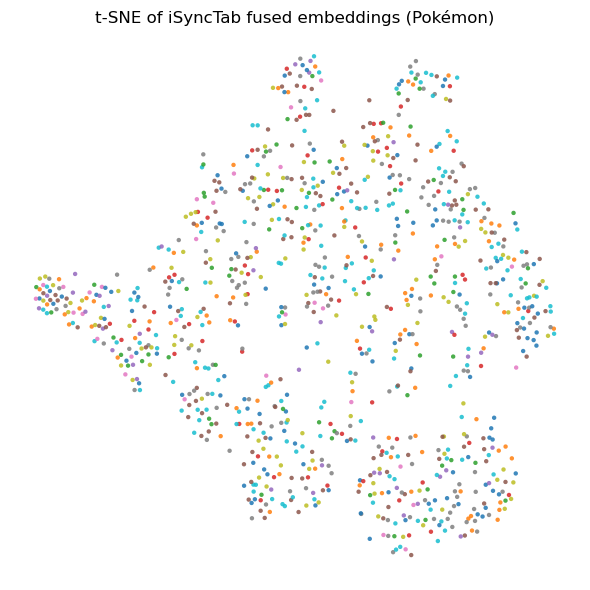

In [ ]:
# ============================================================
# t-SNE Visualization for iSyncTab (Pokémon Dataset)
# ============================================================
import os, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from sklearn.manifold import TSNE
from pathlib import Path
from iSyncTab import iSyncTab

# ------------------------------------------------------------
# Dataset + Collate
# ------------------------------------------------------------
class PokemonDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, max_text_len=32):
        self.df = pd.read_csv(csv_path)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.max_text_len = max_text_len
        self.num_cols  = ["hp","atk","def","spatk","spdef","speed","total","height","weight"]
        self.cat_cols  = ["name","rank","generation","evolves_from","type2"]
        self.text_cols = ["abilities","desc"]

        # keep only rows with existing images
        valid_rows = [i for i in range(len(self.df)) if (self.img_dir/f"{i+1:03d}.png").exists()]
        self.df = self.df.iloc[valid_rows].reset_index(drop=True)

        self.classes = sorted(self.df["type1"].astype(str).unique().tolist())
        self.class_to_id = {c:i for i,c in enumerate(self.classes)}
        self.y = torch.tensor([self.class_to_id[t] for t in self.df["type1"].astype(str)],dtype=torch.long)

        # numeric
        self.x_num = torch.tensor(self.df[self.num_cols].astype(float).to_numpy(copy=True),dtype=torch.float32)
        # categorical
        cat_arrays=[]
        for col in self.cat_cols:
            vals=self.df[col].astype("object").where(pd.notnull(self.df[col]),None)
            uniq=sorted({str(v) for v in vals if v is not None})
            vocab={tok:i for i,tok in enumerate(uniq)}
            ids=[vocab.get(str(v),-1) if v is not None else -1 for v in vals]
            cat_arrays.append(torch.tensor(ids,dtype=torch.long))
        self.x_cat=torch.stack(cat_arrays,dim=1) if cat_arrays else None
        # text
        def tokenize(s):
            toks=str(s).lower().split()[:self.max_text_len]
            ids=[hash(tok)%5000 for tok in toks]
            if len(ids)<self.max_text_len: ids+=[0]*(self.max_text_len-len(ids))
            return ids
        text_arrays=[]
        for col in self.text_cols:
            col_text=self.df[col].fillna("").astype(str)
            tok_col=[tokenize(t) for t in col_text]
            text_arrays.append(torch.tensor(tok_col,dtype=torch.long))
        self.x_text=torch.stack(text_arrays,dim=1)

    def __len__(self): return len(self.df)

    def __getitem__(self,idx):
        img=Image.open(self.img_dir/f"{idx+1:03d}.png").convert("RGB")
        if self.transform: img=self.transform(img)
        x_tab={"num":self.x_num[idx].unsqueeze(0),
               "cat":self.x_cat[idx].unsqueeze(0) if self.x_cat is not None else torch.zeros((1,0),dtype=torch.long),
               "text":self.x_text[idx].unsqueeze(0)}
        return x_tab,img,self.y[idx]

def collate(batch):
    x_tab_b,x_img_b,y_b=zip(*batch)
    x_num_b=torch.cat([b["num"] for b in x_tab_b],dim=0)
    x_cat_b=torch.cat([b["cat"] for b in x_tab_b],dim=0)
    x_text_b=torch.cat([b["text"] for b in x_tab_b],dim=0)
    x_tab_batch={"num":x_num_b,"cat":x_cat_b,"text":x_text_b}
    x_img_b=torch.stack(x_img_b)
    y_b=torch.tensor(y_b)
    return x_tab_batch,x_img_b,y_b

# ------------------------------------------------------------
# Loader
# ------------------------------------------------------------
transform=T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
csv_path="Pokemon/pokemons2.csv"
img_dir="Pokemon/pokemon_images"
dataset=PokemonDataset(csv_path,img_dir,transform)
loader=DataLoader(dataset,batch_size=32,shuffle=False,collate_fn=collate)

# ------------------------------------------------------------
# Model (Pokémon tuned params — adjusted to current signature)
# ------------------------------------------------------------
device="cuda" if torch.cuda.is_available() else "cpu"
params=dict(
    num_tab_features=len(dataset.num_cols)+len(dataset.cat_cols)+len(dataset.text_cols),
    num_classes=len(dataset.classes),
    num_clusters=7,
    metric="variance",
    lambda_fs=0.1287,
    pretrained_resnet=True,
    d_model=192,
    linformer_heads=4,
    linformer_depth=4,
    linformer_k=16,
    device=device
)
model=iSyncTab(**params).to(device)
model.eval()

# ------------------------------------------------------------
# Embedding extraction
# ------------------------------------------------------------
embs,labels=[],[]
with torch.no_grad():
    for x_tab,x_img,y in loader:
        x_img,y=x_img.to(device),y.to(device)
        x_tab={k:v.to(device) for k,v in x_tab.items()}
        out=model(x_tab,x_img)
        z=out.get("embeddings",out["logits"]).detach().cpu().numpy()
        embs.append(z); labels.append(y.cpu().numpy())
embs=np.vstack(embs)
labels=np.concatenate(labels)
print("Embeddings:",embs.shape,"Labels:",labels.shape)

# ------------------------------------------------------------
# t-SNE visualization (CVPR-quality)
# ------------------------------------------------------------
tsne=TSNE(n_components=2,perplexity=30,learning_rate=200,random_state=42)
Z=tsne.fit_transform(embs)
plt.figure(figsize=(6,6))
plt.scatter(Z[:,0],Z[:,1],c=labels,cmap="tab10",s=10,alpha=0.85,edgecolors="none")
plt.title("t-SNE of iSyncTab fused embeddings (Pokémon)")
plt.axis("off")
plt.tight_layout()
plt.savefig("tsne_pokemon.png",dpi=600,bbox_inches="tight")
plt.savefig("tsne_pokemon.pdf",bbox_inches="tight")
plt.show()

# HAM t-SNE

Device: cuda:6
Dataset loaded: 10015 samples | 1 num cols, 4 cat cols


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

Embeddings: (10015, 7) | Labels: (10015,)


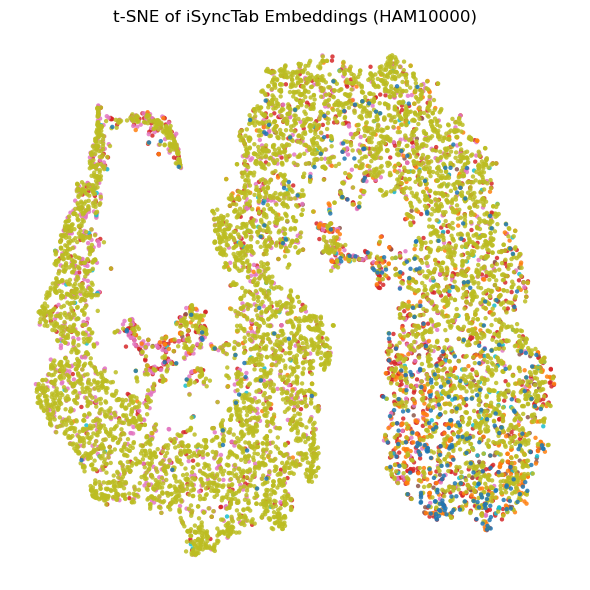

In [ ]:
# ============================================================
# t-SNE Visualization for iSyncTab (HAM10000)
# ============================================================
import os, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
from torchvision import transforms as T
from pathlib import Path
from PIL import Image
from iSyncTab import iSyncTab, set_seed

# ------------------- CONFIG -------------------
CSV_PATH = "HAM10000_metadata_labeled.csv"
IMG_ROOT = "ham_images_link"
DEVICE = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
set_seed(123)
print("Device:", DEVICE)

# ------------------- DATASET -------------------
class HamDataset(Dataset):
    """HAM10000 multimodal dataset for t-SNE (dx = target)."""
    def __init__(self, csv_path, img_root, transform=None):
        df = pd.read_csv(csv_path)
        self.img_root = Path(img_root)
        self.transform = transform

        assert "image_id" in df.columns and "dx" in df.columns
        # Remove `label` column if exists
        if "label" in df.columns:
            df = df.drop(columns=["label"])

        # Encode dx → label
        classes = sorted(df["dx"].astype(str).unique())
        mapping = {c:i for i,c in enumerate(classes)}
        df["label"] = df["dx"].map(mapping)
        self.classes = classes

        # Keep only valid images
        paths, keep_idx = [], []
        for i, row in df.iterrows():
            name = str(row["image_id"])
            p = self.img_root / (name if name.endswith(".jpg") else f"{name}.jpg")
            if p.exists():
                keep_idx.append(i)
                paths.append(p)
        df = df.iloc[keep_idx].reset_index(drop=True)
        self.img_paths = paths
        self.df = df

        exclude = {"image_id", "dx", "label"}
        num_cols, cat_cols = [], []
        for col in df.columns:
            if col in exclude: continue
            if pd.api.types.is_numeric_dtype(df[col]): num_cols.append(col)
            else: cat_cols.append(col)
        self.num_cols, self.cat_cols = num_cols, cat_cols
        self.text_cols = []

        if num_cols:
            num_df = df[num_cols].astype(float).fillna(0.0)
            self.x_num = torch.tensor(num_df.to_numpy(copy=True), dtype=torch.float32)
        else:
            self.x_num = torch.zeros((len(df),0),dtype=torch.float32)

        self.x_cat = None
        if cat_cols:
            cat_arrays = []
            for col in cat_cols:
                vals = df[col].astype(str)
                uniq = sorted(vals.unique())
                vocab = {v:i for i,v in enumerate(uniq)}
                ids = [vocab[v] for v in vals]
                cat_arrays.append(torch.tensor(ids,dtype=torch.long))
            self.x_cat = torch.stack(cat_arrays,dim=1)

        self.x_text = torch.zeros((len(df),1,1),dtype=torch.long)
        self.y = torch.tensor(df["label"].values,dtype=torch.long)

    def __len__(self): return len(self.df)

    def __getitem__(self,idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        x_tab = {
            "num": self.x_num[idx].unsqueeze(0),
            "cat": self.x_cat[idx].unsqueeze(0) if self.x_cat is not None else torch.zeros((1,0),dtype=torch.long),
            "text": self.x_text[idx].unsqueeze(0)
        }
        return x_tab, img, self.y[idx]

def collate(batch):
    x_tab_b,x_img_b,y_b = zip(*batch)
    x_num_b = torch.cat([b["num"] for b in x_tab_b], dim=0)
    x_cat_b = torch.cat([b["cat"] for b in x_tab_b], dim=0) if x_tab_b[0]["cat"].numel() else torch.zeros((len(x_tab_b),0),dtype=torch.long)
    x_text_b = torch.cat([b["text"] for b in x_tab_b],dim=0)
    x_tab_batch = {"num":x_num_b,"cat":x_cat_b,"text":x_text_b}
    x_img_b = torch.stack(x_img_b)
    y_b = torch.tensor(y_b)
    return x_tab_batch,x_img_b,y_b

# ------------------- LOADERS -------------------
transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

ds = HamDataset(CSV_PATH, IMG_ROOT, transform)
loader = DataLoader(ds, batch_size=16, shuffle=False, collate_fn=collate)
print(f"Dataset loaded: {len(ds)} samples | {len(ds.num_cols)} num cols, {len(ds.cat_cols)} cat cols")

# ------------------- MODEL -------------------
params_ham = dict(
    num_tab_features=len(ds.num_cols)+len(ds.cat_cols)+1,
    num_classes=len(ds.classes),
    num_clusters=4,
    metric="kl",
    lambda_fs=0.1030,
    pretrained_resnet=True,
    d_model=128,
    linformer_heads=4,
    linformer_depth=5,
    linformer_k=64,
    device=DEVICE
)
model = iSyncTab(**params_ham).to(DEVICE)
model.eval()

# ------------------- EMBEDDINGS -------------------
embs, labels = [], []
with torch.no_grad():
    for x_tab, x_img, y in loader:
        x_img, y = x_img.to(DEVICE), y.to(DEVICE)
        x_tab = {k:v.to(DEVICE) for k,v in x_tab.items()}
        out = model(x_tab, x_img)
        z = out.get("embeddings", out["logits"]).detach().cpu().numpy()
        embs.append(z)
        labels.append(y.cpu().numpy())

embs = np.vstack(embs)
labels = np.concatenate(labels)
print("Embeddings:", embs.shape, "| Labels:", labels.shape)

# ------------------- t-SNE -------------------
tsne = TSNE(n_components=2, perplexity=35, learning_rate=200, random_state=42)
Z = tsne.fit_transform(embs)

plt.figure(figsize=(6,6))
scatter = plt.scatter(Z[:,0], Z[:,1], c=labels, cmap="tab10", s=10, alpha=0.85, edgecolors="none")
plt.axis("off")
plt.title("t-SNE of iSyncTab Embeddings (HAM10000)")
plt.tight_layout()
plt.savefig("tsne_ham10000.png", dpi=600, bbox_inches="tight")
plt.savefig("tsne_ham10000.pdf", bbox_inches="tight")
plt.show()

# more on ablation (using HAM10000)

In [ ]:
# ===== Build HAM10000 test DataLoader + model_ham (run this first) =====
import torch, pandas as pd
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from pathlib import Path
from iSyncTab import iSyncTab

# If these were defined earlier, we’ll reuse them; otherwise we quickly re-declare minimal bits.
CSV_PATH = globals().get("CSV_PATH", "HAM10000_metadata_labeled.csv")
IMG_ROOT = globals().get("IMG_ROOT", "ham_images_link")

# Minimal dataset+collate if not already present in notebook
if "HamDataset" not in globals():
    from PIL import Image
    class HamDataset(torch.utils.data.Dataset):
        def __init__(self, csv_path, img_root, transform=None):
            df = pd.read_csv(csv_path)
            self.img_root = Path(img_root); self.transform = transform
            assert "image_id" in df.columns, "CSV must contain image_id"
            # target is dx (exclude any existing 'label')
            classes = pd.Categorical(df["dx"].astype(str)).categories.tolist()
            mapping = {c:i for i,c in enumerate(classes)}
            df = df.assign(label=df["dx"].astype(str).map(mapping).astype(int))
            # keep rows with existing images (append .jpg if needed)
            def ensure_jpg(s):
                s = str(s)
                return s if s.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff")) else s + ".jpg"
            keep, paths = [], []
            for i, r in df.iterrows():
                p = self.img_root / ensure_jpg(r["image_id"])
                if p.exists():
                    keep.append(i); paths.append(p)
            self.df = df.iloc[keep].reset_index(drop=True)
            self.img_paths = paths
            self.classes = classes
            self.y = torch.tensor(self.df["label"].astype(int).to_numpy(), dtype=torch.long)
            # tabular features: everything except image_id, dx, label
            exclude = {"image_id","dx","label"}
            num_cols, cat_cols = [], []
            for c in self.df.columns:
                if c in exclude: continue
                if pd.api.types.is_numeric_dtype(self.df[c]): num_cols.append(c)
                else: cat_cols.append(c)
            self.num_cols, self.cat_cols, self.text_cols = num_cols, cat_cols, []
            self.x_num = torch.tensor(self.df[self.num_cols].astype(float).fillna(0.0).to_numpy(copy=True),
                                      dtype=torch.float32) if self.num_cols else torch.zeros((len(self.df),0),dtype=torch.float32)
            self._cat_vocabs = {}
            if self.cat_cols:
                cat_arrays=[]
                for c in self.cat_cols:
                    vals = self.df[c].astype("object")
                    uniq = sorted({str(v) for v in vals.dropna().unique().tolist()})
                    vocab = {t:i for i,t in enumerate(uniq)}; self._cat_vocabs[c]=vocab
                    ids = [vocab.get(str(v),-1) if pd.notna(v) else -1 for v in vals]
                    cat_arrays.append(torch.tensor(ids,dtype=torch.long))
                self.x_cat = torch.stack(cat_arrays, dim=1)
            else:
                self.x_cat = None
            self.x_text = torch.zeros((len(self.df),1,1), dtype=torch.long)
        def __len__(self): return len(self.y)
        def __getitem__(self, idx):
            img = Image.open(self.img_paths[idx]).convert("RGB")
            if self.transform: img = self.transform(img)
            x_num  = self.x_num[idx]
            x_cat  = self.x_cat[idx] if self.x_cat is not None else torch.zeros(0, dtype=torch.long)
            x_text = self.x_text[idx]
            y      = self.y[idx]
            x_tab = {"num": x_num.unsqueeze(0), "cat": x_cat.unsqueeze(0), "text": x_text.unsqueeze(0)}
            return x_tab, img, y

    def collate(batch):
        x_tab_b, x_img_b, y_b = zip(*batch)
        x_num_b  = torch.cat([b["num"]  for b in x_tab_b], dim=0)
        if x_tab_b[0]["cat"].numel():
            x_cat_b = torch.cat([b["cat"] for b in x_tab_b], dim=0)
        else:
            x_cat_b = torch.zeros((len(x_tab_b),0), dtype=torch.long)
        x_text_b = torch.cat([b["text"] for b in x_tab_b], dim=0)
        x_tab_batch = {"num": x_num_b, "cat": x_cat_b, "text": x_text_b}
        x_img_b = torch.stack(x_img_b)
        y_b     = torch.tensor(y_b)
        return x_tab_batch, x_img_b, y_b

# Transforms
transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Dataset + split
ds = HamDataset(CSV_PATH, IMG_ROOT, transform=transform)
N = len(ds)
n_train = int(round(0.64*N)); n_val = int(round(0.16*N)); n_test = N - n_train - n_val
g = torch.Generator().manual_seed(123)
ds_train, ds_val, ds_test = random_split(ds, [n_train, n_val, n_test], generator=g)

# DataLoaders (only test is needed for ablations)
device = torch.device("cuda:6" if torch.cuda.is_available() and torch.cuda.device_count()>6 else ("cuda" if torch.cuda.is_available() else "cpu"))
pin = (device.type == "cuda")
dl_test = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin, collate_fn=collate)

# Model with your tuned HAM params (omit num_memory_tokens if constructor doesn’t support it)
num_tab_features = len(ds.num_cols) + len(ds.cat_cols) + 1  # +1 dummy text chan
num_classes = len(ds.classes)
model_ham = iSyncTab(
    num_tab_features=num_tab_features,
    num_classes=num_classes,
    d_model=128,
    linformer_heads=4,
    linformer_depth=5,
    linformer_k=64,
    num_clusters=4,
    metric="kl",
    lambda_fs=0.10303680421449747,
    pretrained_resnet=True,
    device=str(device)
).to(device).eval()

# Hand to your ablation pack:
loader = dl_test
model  = model_ham
print(f"Ready: {len(ds_test)} test samples | num cols={len(ds.num_cols)} cat cols={len(ds.cat_cols)} | device={device}")

Ready: 2003 test samples | num cols=1 cat cols=4 | device=cuda:6


# Inference-only ablation pack (HAM10000)

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=


=== HAM10000 Ablation Summary ===
      Tab Shuffle ↓  Tab Drop ↓  Img Blur σ  kNN-Agree@5
0.00          48.88       48.88         0.0        82.33
0.10          48.88       48.88         0.5        82.33
0.25          48.98       48.88         1.0        82.33
0.50          49.08       48.78         1.5        82.33
0.75          48.73       48.38         2.0        82.33
1.00          49.08       48.48         NaN        82.33

Expected Calibration Error (ECE): 0.259


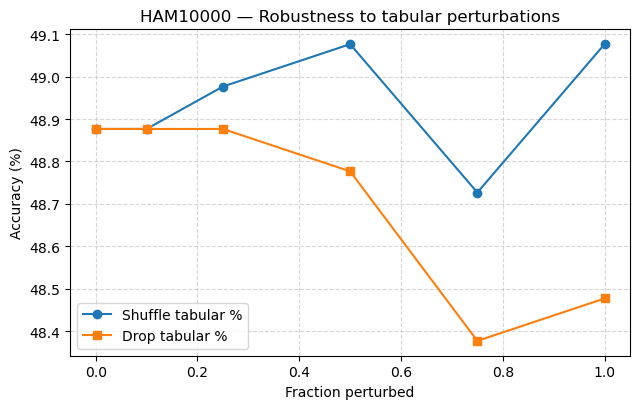

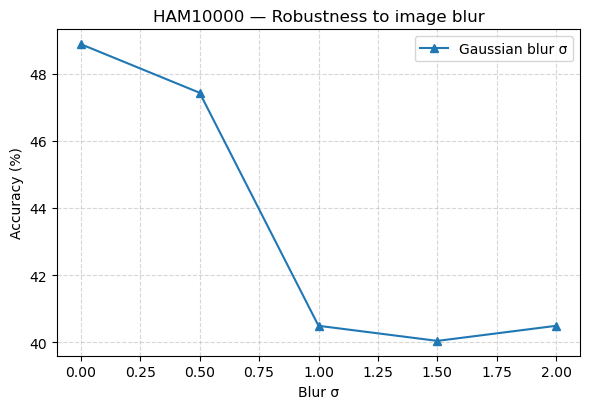

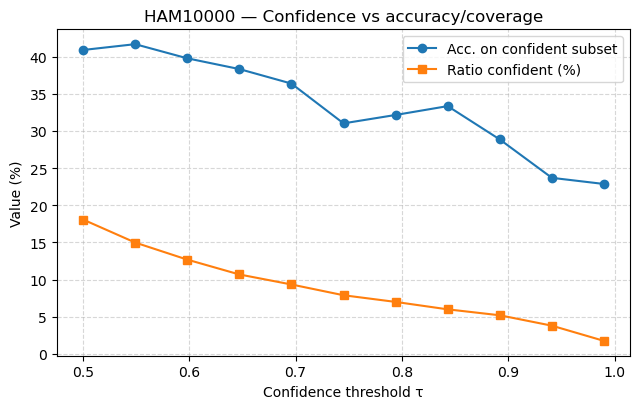

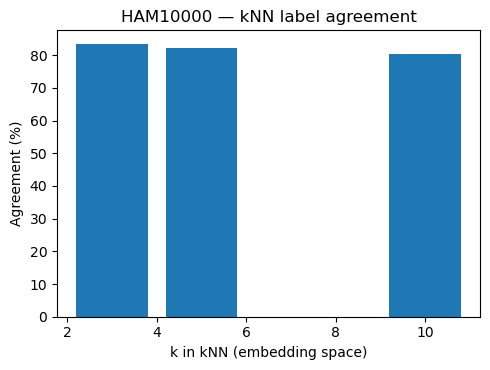

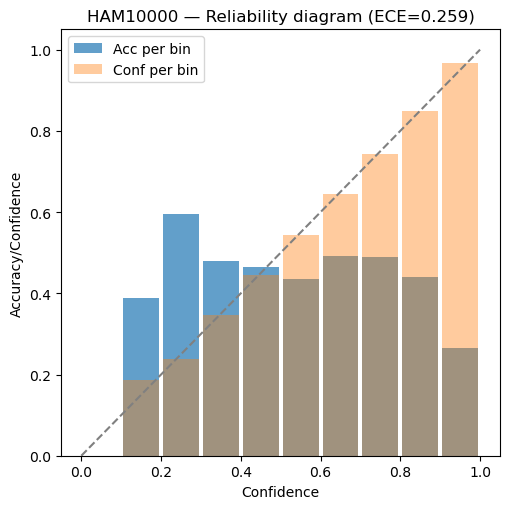

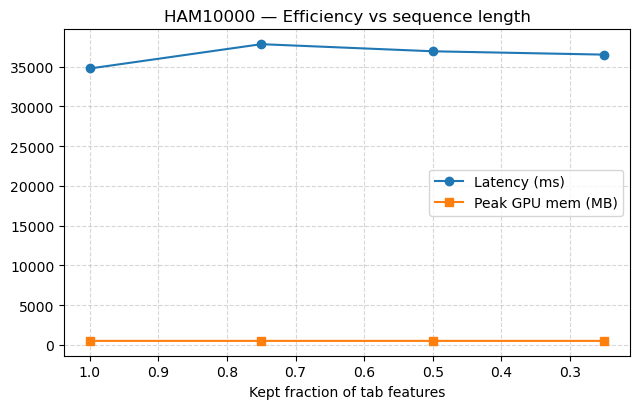

In [ ]:
# ===================== Inference-only ablation pack (HAM10000, fixed) =====================
import os, time, math, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
import torchvision.transforms.functional as TF

plt.rcParams.update({"savefig.facecolor":"white","figure.facecolor":"white"})
device = next(model.parameters()).device
model.eval()

# -------------------- Helpers --------------------
def _to_device(x_tab, x_img, y=None, dev=device):
    x_tab = {k:v.to(dev) for k,v in x_tab.items()}
    x_img = x_img.to(dev)
    if y is not None: y = y.to(dev)
    return x_tab, x_img, y

@torch.no_grad()
def predict_loader(loader, perturb=None):
    logits_all, probs_all, preds_all, y_all, embs_all = [], [], [], [], []
    for x_tab, x_img, y in loader:
        if perturb: x_tab, x_img = perturb(x_tab, x_img)
        x_tab, x_img, y = _to_device(x_tab, x_img, y)
        out = model(x_tab, x_img)
        logits = out["logits"]
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(1)
        emb = out.get("embeddings", logits)
        logits_all.append(logits.cpu()); probs_all.append(probs.cpu())
        preds_all.append(preds.cpu()); y_all.append(y.cpu()); embs_all.append(emb.cpu())
    logits = torch.cat(logits_all); probs = torch.cat(probs_all)
    preds  = torch.cat(preds_all);  y = torch.cat(y_all)
    embs   = torch.cat(embs_all).numpy()
    return logits.numpy(), probs.numpy(), preds.numpy(), y.numpy(), embs

# -------------------- Perturbations --------------------
def make_tab_shuffle_perturber(p):
    def _perturb(x_tab, x_img):
        x_tab = {k:v.clone() for k,v in x_tab.items()}
        n_num = x_tab["num"].shape[1] if x_tab["num"].ndim==2 else 0
        n_cat = x_tab["cat"].shape[1] if x_tab["cat"].ndim==2 else 0
        idx_all = np.arange(n_num+n_cat)
        k = int(round(p*len(idx_all)))
        if k>0:
            cols = np.random.choice(idx_all,size=k,replace=False)
            B = x_tab["num"].shape[0]
            for c in cols:
                if c<n_num:
                    perm = torch.randperm(B)
                    x_tab["num"][:,c] = x_tab["num"][:,c][perm]
                else:
                    c2=c-n_num; perm=torch.randperm(B)
                    x_tab["cat"][:,c2]=x_tab["cat"][:,c2][perm]
        return x_tab,x_img
    return _perturb

def make_tab_drop_perturber(p):
    def _perturb(x_tab,x_img):
        x_tab={k:v.clone() for k,v in x_tab.items()}
        n_num=x_tab["num"].shape[1] if x_tab["num"].ndim==2 else 0
        n_cat=x_tab["cat"].shape[1] if x_tab["cat"].ndim==2 else 0
        idx_all=np.arange(n_num+n_cat)
        k=int(round(p*len(idx_all)))
        if k>0:
            cols=np.random.choice(idx_all,size=k,replace=False)
            num_mean=x_tab["num"].mean(0) if n_num>0 else None
            for c in cols:
                if c<n_num:
                    x_tab["num"][:,c]=num_mean[c]
                else:
                    c2=c-n_num; x_tab["cat"][:,c2]=-1
        return x_tab,x_img
    return _perturb

def make_img_blur_perturber(sigma):
    def _perturb(x_tab,x_img):
        # skip blur if sigma <= 0
        if sigma <= 0.0:
            return x_tab, x_img
        x_img=x_img.clone(); k=max(3,int(2*round(3*sigma)+1))
        for i in range(x_img.shape[0]):
            x_img[i]=TF.gaussian_blur(x_img[i],kernel_size=k,sigma=sigma)
        return x_tab,x_img
    return _perturb

# -------------------- 1. Robustness --------------------
ps=[0.0,0.1,0.25,0.5,0.75,1.0]; sigmas=[0.0,0.5,1.0,1.5,2.0]
def eval_accuracy(loader,perturb=None):
    _,_,preds,y,_=predict_loader(loader,perturb)
    return accuracy_score(y,preds)*100

acc_shuffle=[eval_accuracy(loader,make_tab_shuffle_perturber(p)) for p in ps]
acc_drop=[eval_accuracy(loader,make_tab_drop_perturber(p)) for p in ps]
acc_blur=[eval_accuracy(loader,make_img_blur_perturber(s)) for s in sigmas]

plt.figure(figsize=(6.5,4.2))
plt.plot(ps,acc_shuffle,'-o',label='Shuffle tabular %')
plt.plot(ps,acc_drop,'-s',label='Drop tabular %')
plt.xlabel("Fraction perturbed"); plt.ylabel("Accuracy (%)")
plt.title("HAM10000 — Robustness to tabular perturbations")
plt.grid(True,ls='--',alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig("ham_robustness_tabular.png",dpi=600,bbox_inches='tight')

plt.figure(figsize=(6.0,4.2))
plt.plot(sigmas,acc_blur,'-^',label='Gaussian blur σ')
plt.xlabel("Blur σ"); plt.ylabel("Accuracy (%)")
plt.title("HAM10000 — Robustness to image blur")
plt.grid(True,ls='--',alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig("ham_robustness_image.png",dpi=600,bbox_inches='tight')

# -------------------- 2. Confidence & kNN consistency --------------------
taus=np.linspace(0.5,0.99,11)
_,probs,preds,y,embs=predict_loader(loader)
conf=probs.max(1)
idx_conf=[np.where(conf>=t)[0] for t in taus]
acc_conf=[accuracy_score(y[idx],preds[idx])*100 if len(idx)>0 else np.nan for idx in idx_conf]
ratio_conf=[len(idx)/len(y)*100 for idx in idx_conf]
nbrs=NearestNeighbors(n_neighbors=11,metric='euclidean').fit(embs)
neigh=nbrs.kneighbors(embs,return_distance=False)[:,1:]
agree=[]
for k in [3,5,10]:
    a=[(preds[neigh[i,:k]]==preds[i]).mean() for i in range(len(y))]
    agree.append(100*np.mean(a))

plt.figure(figsize=(6.5,4.2))
plt.plot(taus,acc_conf,'-o',label='Acc. on confident subset')
plt.plot(taus,ratio_conf,'-s',label='Ratio confident (%)')
plt.xlabel("Confidence threshold τ"); plt.ylabel("Value (%)")
plt.title("HAM10000 — Confidence vs accuracy/coverage")
plt.grid(True,ls='--',alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig("ham_confidence_curve.png",dpi=600,bbox_inches='tight')

plt.figure(figsize=(5,3.8))
plt.bar([3,5,10],agree,width=1.6)
plt.xlabel("k in kNN (embedding space)"); plt.ylabel("Agreement (%)")
plt.title("HAM10000 — kNN label agreement"); plt.tight_layout()
plt.savefig("ham_knn_agreement.png",dpi=600,bbox_inches='tight')

# -------------------- 3. Calibration --------------------
bins=np.linspace(0.0,1.0,11)
bin_ids=np.digitize(conf,bins)-1
acc_bin,conf_bin,cnt_bin=[],[],[]
for b in range(len(bins)-1):
    idx=np.where(bin_ids==b)[0]
    if len(idx)==0: acc_bin.append(0.0); conf_bin.append(0.0); cnt_bin.append(0)
    else:
        acc_bin.append(accuracy_score(y[idx],preds[idx]))
        conf_bin.append(conf[idx].mean()); cnt_bin.append(len(idx))
acc_bin,conf_bin=np.array(acc_bin),np.array(conf_bin)
ece=np.sum(np.abs(acc_bin-conf_bin)*(np.array(cnt_bin)/len(y)))
plt.figure(figsize=(5.2,5.2))
plt.plot([0,1],[0,1],'--',color='gray')
plt.bar(bins[:-1]+0.05,acc_bin,width=0.09,alpha=0.7,label='Acc per bin')
plt.bar(bins[:-1]+0.05,conf_bin,width=0.09,alpha=0.4,label='Conf per bin')
plt.xlabel("Confidence"); plt.ylabel("Accuracy/Confidence")
plt.title(f"HAM10000 — Reliability diagram (ECE={ece:.3f})")
plt.legend(); plt.tight_layout()
plt.savefig("ham_reliability.png",dpi=600,bbox_inches='tight')

# -------------------- 4. Efficiency --------------------
def eval_latency_mem(loader,keep_fracs=(1.0,0.75,0.5,0.25)):
    n_num=next(iter(loader))[0]["num"].shape[1]
    n_cat=next(iter(loader))[0]["cat"].shape[1]
    res=[]
    for f in keep_fracs:
        kn=int(round(n_num*f)); kc=int(round(n_cat*f))
        idx_num=np.arange(n_num)[:kn]; idx_cat=np.arange(n_cat)[:kc]
        def pert(x_tab,x_img):
            x_tab={k:v.clone() for k,v in x_tab.items()}
            x_tab["num"]=x_tab["num"][:,idx_num]
            x_tab["cat"]=x_tab["cat"][:,idx_cat]
            return x_tab,x_img
        if device.type=='cuda': torch.cuda.reset_peak_memory_stats(device)
        t0=time.time(); predict_loader(loader,pert); t1=time.time()
        peak=torch.cuda.max_memory_allocated(device)/1e6 if device.type=='cuda' else 0
        res.append((f,(t1-t0),peak))
    return res

eff=eval_latency_mem(loader)
fracs,lat,mem=zip(*eff)
plt.figure(figsize=(6.5,4.2))
plt.plot(fracs,np.array(lat)*1000,'-o',label='Latency (ms)')
if device.type=='cuda': plt.plot(fracs,mem,'-s',label='Peak GPU mem (MB)')
plt.gca().invert_xaxis()
plt.xlabel("Kept fraction of tab features")
plt.title("HAM10000 — Efficiency vs sequence length")
plt.grid(True,ls='--',alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig("ham_efficiency.png",dpi=600,bbox_inches='tight')

# -------------------- Summary table --------------------
import pandas as pd
df_summary=pd.DataFrame({
    "Tab Shuffle ↓":acc_shuffle,
    "Tab Drop ↓":acc_drop,
    "Img Blur σ":sigmas+[np.nan]*(len(ps)-len(sigmas))
},index=[f"{p:.2f}" for p in ps])
df_summary["kNN-Agree@5"]=agree[1]
print("\n=== HAM10000 Ablation Summary ===")
print(df_summary.round(2))
print(f"\nExpected Calibration Error (ECE): {ece:.3f}")

# Extra sanity & stress tests (HAM10000)

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

Mode=full         | Acc =  48.88 % (n=2003)


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

Mode=image_only   | Acc =  48.48 % (n=2003)


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

...

Mode=shuffle_img  | Acc =  44.83 % (n=2003)


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=


=== Augmentation consistency / stress ===
Base accuracy:  48.88 %
TTA majority-vote accuracy (n_aug=5):  55.62 %
Fraction of samples with any label change across aug:  56.91 %


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=


=== Per-class accuracy summary (top 10 by support) ===
   class_id  support  accuracy
5         5     1330     67.52
2         2      237      0.00
4         4      229     31.88
1         1       89      2.25
0         0       65      9.23
3         3       27      0.00
6         6       26      0.00

=== Bucketed per-class accuracy (by support) ===
        count   mean
bucket              
head        2  33.76
medium      3  14.45
tail        2   0.00

[Done] Extra sanity & stress tests complete.
Saved figures:
  - ham_modality_sanity_stress.png
  - ham_tta_accuracy.png
  - ham_per_class_accuracy.png


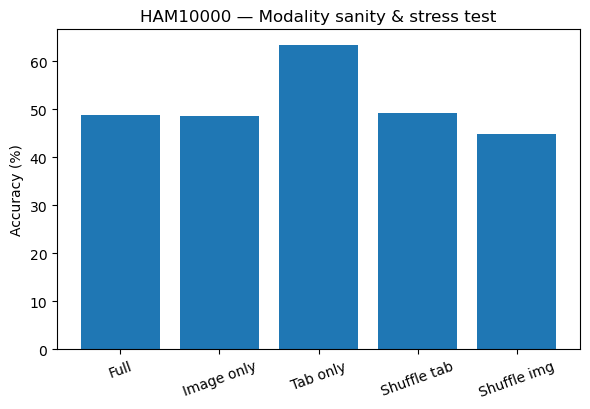

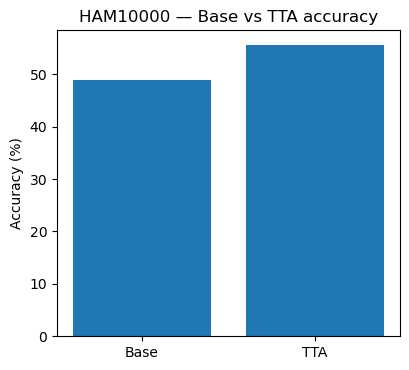

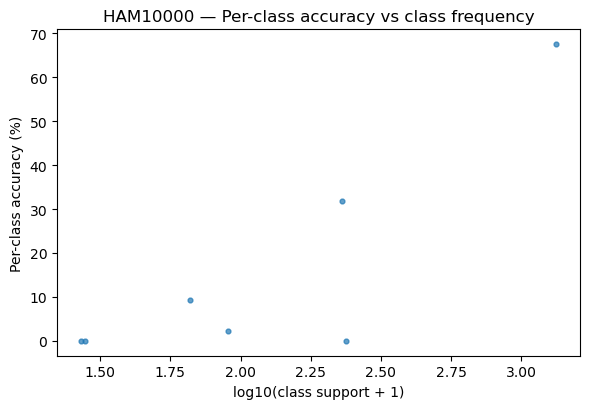

In [ ]:
# ===================== Extra sanity & stress tests (HAM10000) =====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score
import torchvision.transforms.functional as TF

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

device = next(model.parameters()).device
model.eval()

# Sanity check: verify predict_loader exists
try:
    _ = predict_loader
except NameError as e:
    raise RuntimeError("predict_loader is not defined. "
                       "Please run your previous ablation pack cell first.") from e

# -------------------------------------------------------------------
# 1. Modality sanity & stress tests
#    - Full (image + tabular)
#    - Image-only (tabular wiped)
#    - Tab-only (image wiped / averaged)
#    - Mismatched modalities (shuffle tab or images)
# -------------------------------------------------------------------
def _clone_batch(x_tab, x_img):
    x_tab = {k: v.clone() for k, v in x_tab.items()}
    x_img = x_img.clone()
    return x_tab, x_img

def make_modality_perturber(mode):
    """
    mode ∈ {"full", "image_only", "tab_only", "shuffle_tab", "shuffle_img"}.
    """
    assert mode in {"full", "image_only", "tab_only", "shuffle_tab", "shuffle_img"}
    def _perturb(x_tab, x_img):
        x_tab, x_img = _clone_batch(x_tab, x_img)
        B = x_img.shape[0]

        if mode == "full":
            return x_tab, x_img

        # Prepare some useful stats
        if "num" in x_tab and x_tab["num"] is not None and x_tab["num"].ndim == 2:
            num_mean = x_tab["num"].mean(dim=0, keepdim=True)
        else:
            num_mean = None

        if mode == "image_only":
            # Keep images, wipe tabular signal
            if num_mean is not None:
                x_tab["num"][:] = num_mean
            if "cat" in x_tab and x_tab["cat"] is not None:
                x_tab["cat"][:] = -1   # unseen category id
            return x_tab, x_img

        if mode == "tab_only":
            # Keep tabular, replace images with a blurred / averaged template
            # (compute mean over batch, then blur)
            mean_img = x_img.mean(dim=0, keepdim=True)
            # slight blur to make it clearly non-informative
            k = 9
            sig = 2.0
            mean_img_blur = TF.gaussian_blur(mean_img, kernel_size=k, sigma=sig)
            x_img[:] = mean_img_blur
            return x_tab, x_img

        if mode == "shuffle_tab":
            # Shuffle tabular rows within the batch (destroy alignment with image)
            perm = torch.randperm(B)
            if "num" in x_tab and x_tab["num"] is not None:
                x_tab["num"] = x_tab["num"][perm]
            if "cat" in x_tab and x_tab["cat"] is not None:
                x_tab["cat"] = x_tab["cat"][perm]
            return x_tab, x_img

        if mode == "shuffle_img":
            # Shuffle images within the batch (destroy alignment with tabular)
            perm = torch.randperm(B)
            x_img = x_img[perm]
            return x_tab, x_img

        return x_tab, x_img

    return _perturb

@torch.no_grad()
def eval_modality_modes(loader, modes):
    results = {}
    for m in modes:
        _, _, preds, y, _ = predict_loader(loader, perturb=make_modality_perturber(m))
        acc = accuracy_score(y, preds) * 100
        results[m] = acc
        print(f"Mode={m:12s} | Acc = {acc:6.2f} % (n={len(y)})")
    return results

modes = ["full", "image_only", "tab_only", "shuffle_tab", "shuffle_img"]
modality_results = eval_modality_modes(loader, modes)

# Plot as bar chart for supplementary
plt.figure(figsize=(6.0, 4.2))
names = ["Full", "Image only", "Tab only", "Shuffle tab", "Shuffle img"]
vals = [modality_results[m] for m in modes]
plt.bar(range(len(names)), vals)
plt.xticks(range(len(names)), names, rotation=20)
plt.ylabel("Accuracy (%)")
plt.title("HAM10000 — Modality sanity & stress test")
plt.tight_layout()
plt.savefig("ham_modality_sanity_stress.png", dpi=600, bbox_inches="tight")

# -------------------------------------------------------------------
# 2. Augmentation consistency / stress test
#    - Random geometric + photometric transforms
#    - Measure:
#       * Base accuracy
#       * TTA majority-vote accuracy
#       * Fraction of samples whose predictions change across aug samples
# -------------------------------------------------------------------
def random_augment_batch(x_img):
    x_img = x_img.clone()
    B = x_img.shape[0]
    for i in range(B):
        img = x_img[i]

        # Random horizontal flip
        if torch.rand(1).item() < 0.5:
            img = TF.hflip(img)

        # Small random rotation
        angle = np.random.uniform(-15, 15)
        img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)

        # Color jitter-ish: brightness / contrast
        # (implemented manually to avoid depending on transforms.ColorJitter)
        b = np.random.uniform(0.9, 1.1)
        c = np.random.uniform(0.9, 1.1)
        mean = img.mean(dim=(1, 2), keepdim=True)
        img = (img - mean) * c + mean
        img = img * b

        # Tiny Gaussian noise
        noise = torch.randn_like(img) * 0.01
        img = img + noise

        x_img[i] = img.clamp(min=0.0, max=1.0)  # assume normalized in [0,1] or close
    return x_img

@torch.no_grad()
def predict_with_aug(loader, n_aug=5):
    # Get base predictions once
    _, probs_base, preds_base, y, _ = predict_loader(loader, perturb=None)
    preds_base = preds_base
    y = y

    # For each augmentation sample, collect predictions
    all_aug_preds = []
    for j in range(n_aug):
        logits_all, probs_all, preds_all, _, _ = [], [], [], [], []
        for x_tab, x_img, y_batch in loader:
            x_tab, x_img, _ = _to_device(x_tab, x_img, None, dev=device)
            x_img_aug = random_augment_batch(x_img)
            out = model(x_tab, x_img_aug)
            probs = torch.softmax(out["logits"], dim=1)
            preds = probs.argmax(1)
            preds_all.append(preds.cpu())
        preds_all = torch.cat(preds_all).numpy()
        all_aug_preds.append(preds_all)

    all_aug_preds = np.stack(all_aug_preds, axis=1)  # [N, n_aug]

    # Majority vote across augmentations
    maj_preds = []
    for i in range(all_aug_preds.shape[0]):
        vals, counts = np.unique(all_aug_preds[i], return_counts=True)
        maj_preds.append(vals[counts.argmax()])
    maj_preds = np.array(maj_preds)

    # Metrics
    base_acc = accuracy_score(y, preds_base) * 100
    tta_acc = accuracy_score(y, maj_preds) * 100
    # Fraction of samples that ever change label across augmentations
    change_mask = (all_aug_preds != preds_base[:, None]).any(axis=1)
    frac_changed = change_mask.mean() * 100

    print("\n=== Augmentation consistency / stress ===")
    print(f"Base accuracy: {base_acc:6.2f} %")
    print(f"TTA majority-vote accuracy (n_aug={n_aug}): {tta_acc:6.2f} %")
    print(f"Fraction of samples with any label change across aug: {frac_changed:6.2f} %")

    return {
        "base_acc": base_acc,
        "tta_acc": tta_acc,
        "frac_changed": frac_changed,
        "y": y,
        "preds_base": preds_base,
        "maj_preds": maj_preds,
        "all_aug_preds": all_aug_preds,
    }

aug_results = predict_with_aug(loader, n_aug=5)

# Small bar plot: base vs TTA accuracy
plt.figure(figsize=(4.2, 3.8))
plt.bar([0, 1], [aug_results["base_acc"], aug_results["tta_acc"]])
plt.xticks([0, 1], ["Base", "TTA"])
plt.ylabel("Accuracy (%)")
plt.title("HAM10000 — Base vs TTA accuracy")
plt.tight_layout()
plt.savefig("ham_tta_accuracy.png", dpi=600, bbox_inches="tight")

# -------------------------------------------------------------------
# 3. Per-class accuracy vs class frequency
#    (long-tail / fairness sanity check)
# -------------------------------------------------------------------
# Re-use base predictions & labels from the earlier call
_, _, preds_full, y_full, _ = predict_loader(loader, perturb=None)

labels = y_full
preds  = preds_full

# Compute per-class accuracy and support
classes = np.unique(labels)
per_class_acc = []
per_class_cnt = []
for c in classes:
    idx = np.where(labels == c)[0]
    per_class_cnt.append(len(idx))
    if len(idx) > 0:
        per_class_acc.append(accuracy_score(labels[idx], preds[idx]) * 100)
    else:
        per_class_acc.append(np.nan)

per_class_acc = np.array(per_class_acc)
per_class_cnt = np.array(per_class_cnt)

df_pc = pd.DataFrame({
    "class_id": classes,
    "support": per_class_cnt,
    "accuracy": per_class_acc,
})
df_pc = df_pc.sort_values("support", ascending=False)

print("\n=== Per-class accuracy summary (top 10 by support) ===")
print(df_pc.head(10).round(2))

# Simple head / medium / tail bucket summary (by support quantiles)
quantiles = df_pc["support"].quantile([0.33, 0.67]).values
q1, q2 = quantiles[0], quantiles[1]

def _bucket(s):
    if s >= q2: return "head"
    if s >= q1: return "medium"
    return "tail"

df_pc["bucket"] = df_pc["support"].apply(_bucket)
bucket_summary = df_pc.groupby("bucket")["accuracy"].agg(["count", "mean"])
print("\n=== Bucketed per-class accuracy (by support) ===")
print(bucket_summary.round(2))

# Scatter: log10 support vs per-class accuracy
plt.figure(figsize=(6.0, 4.2))
x = np.log10(df_pc["support"] + 1)
y_sc = df_pc["accuracy"]
plt.scatter(x, y_sc, s=12, alpha=0.7)
plt.xlabel("log10(class support + 1)")
plt.ylabel("Per-class accuracy (%)")
plt.title("HAM10000 — Per-class accuracy vs class frequency")
plt.tight_layout()
plt.savefig("ham_per_class_accuracy.png", dpi=600, bbox_inches="tight")

print("\n[Done] Extra sanity & stress tests complete.")
print("Saved figures:")
print("  - ham_modality_sanity_stress.png")
print("  - ham_tta_accuracy.png")
print("  - ham_per_class_accuracy.png")

# Extra diagnostics pack (HAM10000)

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

Base accuracy on loader: 48.88% (N=2003)

=== Top-10 most frequent confusions (true → predicted) ===
 1. true=5 → pred=4 | count=254
 2. true=2 → pred=5 | count=140
 3. true=4 → pred=5 | count=130
 4. true=5 → pred=3 | count=108
 5. true=2 → pred=4 | count=65
 6. true=5 → pred=0 | count=55
 7. true=1 → pred=5 | count=50
 8. true=0 → pred=5 | count=42
 9. true=4 → pred=3 | count=22
10. true=3 → pred=5 | count=20
Top-1 accuracy: 48.88%
Top-2 accuracy: 65.80%
Top-3 accuracy: 75.04%
Top-5 accuracy: 87.72%

Mean margin (correct): 0.150
Mean margin (wrong)  : 0.181

Detected features: 1 numeric, 4 categorical

=== Per-feature permutation importance (accuracy drop, % points) ===
Baseline accuracy: 48.88%


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

num_00: acc= 48.88% | drop=  0.00 pts


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

...

cat_01: acc= 48.88% | drop=  0.00 pts


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

cat_02: acc= 48.93% | drop= -0.05 pts


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

cat_03: acc= 48.63% | drop=  0.25 pts

Top-15 most important tabular features (by accuracy drop):
  kind  idx  acc_drop   feat
4  cat    3      0.25  cat_3
0  num    0      0.00  num_0
1  cat    0      0.00  cat_0
2  cat    1      0.00  cat_1
3  cat    2     -0.05  cat_2

[Done] Extra diagnostics pack finished.
Saved figures:
  - ham_confusion_matrix_norm.png
  - ham_topk_accuracy.png
  - ham_margin_hist.png
  - ham_tab_feature_importance.png


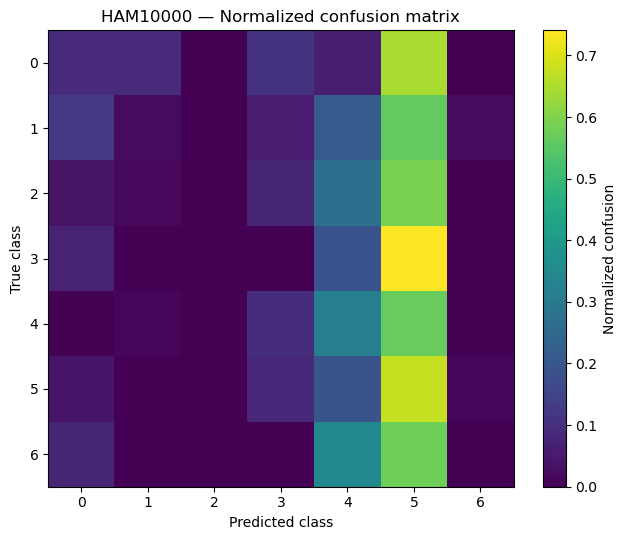

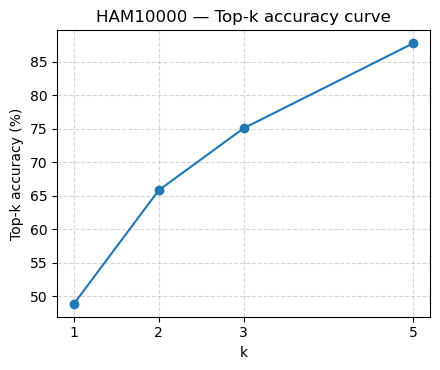

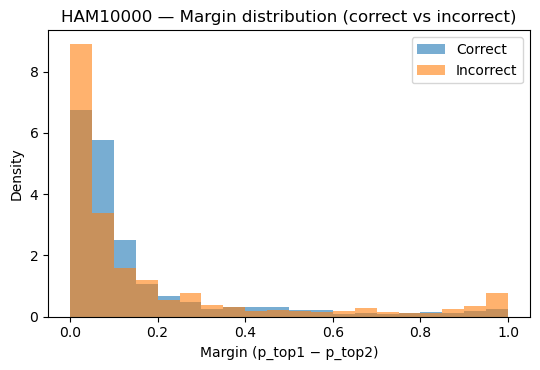

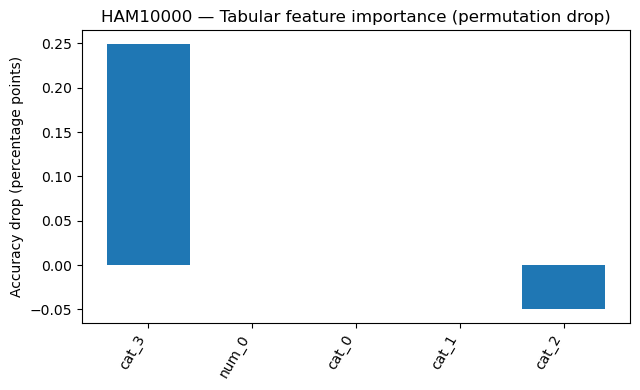

In [ ]:
# ===================== Extra diagnostics pack (HAM10000) =====================
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, top_k_accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

device = next(model.parameters()).device
model.eval()

# Sanity: predict once and cache
logits, probs, preds, y, embs = predict_loader(loader, perturb=None)
num_classes = len(np.unique(y))
base_acc = accuracy_score(y, preds) * 100
print(f"Base accuracy on loader: {base_acc:.2f}% (N={len(y)})")

# -------------------------------------------------------------------
# 1. Confusion matrix + normalized confusion
# -------------------------------------------------------------------
cm = confusion_matrix(y, preds, labels=np.arange(num_classes))
with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm[np.isnan(cm_norm)] = 0.0

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_norm, interpolation="nearest", aspect="auto")
plt.colorbar(label="Normalized confusion")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("HAM10000 — Normalized confusion matrix")
plt.tight_layout()
plt.savefig("ham_confusion_matrix_norm.png", dpi=600, bbox_inches="tight")

# Print top-10 most confused pairs (excluding diagonal)
conf_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i == j:
            continue
        if cm[i, j] > 0:
            conf_pairs.append((cm[i, j], i, j))
conf_pairs.sort(reverse=True)
print("\n=== Top-10 most frequent confusions (true → predicted) ===")
for k in range(min(10, len(conf_pairs))):
    c, i, j = conf_pairs[k]
    print(f"{k+1:2d}. true={i} → pred={j} | count={c}")

# -------------------------------------------------------------------
# 2. Top-k accuracy curve (k = 1..5)
# -------------------------------------------------------------------
ks = [1, 2, 3, 5]
topk_accs = []
for k in ks:
    # sklearn's top_k_accuracy_score expects prob array [N, C]
    acc_k = top_k_accuracy_score(y, probs, k=k) * 100
    topk_accs.append(acc_k)
    print(f"Top-{k} accuracy: {acc_k:.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, topk_accs, "-o")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Top-k accuracy (%)")
plt.title("HAM10000 — Top-k accuracy curve")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ham_topk_accuracy.png", dpi=600, bbox_inches="tight")

# -------------------------------------------------------------------
# 3. Margin / confidence separation
#    margin = p_top1 - p_top2, compare distribution for correct vs wrong
# -------------------------------------------------------------------
sorted_probs = np.sort(probs, axis=1)[:, ::-1]
top1 = sorted_probs[:, 0]
top2 = sorted_probs[:, 1] if sorted_probs.shape[1] > 1 else np.zeros_like(top1)
margins = top1 - top2

correct = (preds == y)
margins_correct = margins[correct]
margins_wrong   = margins[~correct]

print(f"\nMean margin (correct): {margins_correct.mean():.3f}")
print(f"Mean margin (wrong)  : {margins_wrong.mean():.3f}")

plt.figure(figsize=(5.5, 3.8))
bins = np.linspace(0.0, 1.0, 21)
plt.hist(margins_correct, bins=bins, alpha=0.6, label="Correct", density=True)
plt.hist(margins_wrong,   bins=bins, alpha=0.6, label="Incorrect", density=True)
plt.xlabel("Margin (p_top1 − p_top2)")
plt.ylabel("Density")
plt.title("HAM10000 — Margin distribution (correct vs incorrect)")
plt.legend()
plt.tight_layout()
plt.savefig("ham_margin_hist.png", dpi=600, bbox_inches="tight")

# -------------------------------------------------------------------
# 4. Per-feature tabular importance via permutation
#    (accuracy drop when shuffling one feature at a time)
# -------------------------------------------------------------------
# We assume x_tab is {"num": tensor[B, n_num], "cat": tensor[B, n_cat]}.
# We'll get n_num and n_cat from a single batch.
batch = next(iter(loader))
x_tab0, x_img0, _ = batch
n_num = x_tab0["num"].shape[1] if ("num" in x_tab0 and x_tab0["num"].ndim == 2) else 0
n_cat = x_tab0["cat"].shape[1] if ("cat" in x_tab0 and x_tab0["cat"].ndim == 2) else 0
print(f"\nDetected features: {n_num} numeric, {n_cat} categorical")

def make_single_feature_shuffler(idx, kind):
    """
    kind ∈ {"num", "cat"}; idx is column index in that group.
    """
    assert kind in {"num", "cat"}
    def _perturb(x_tab, x_img):
        x_tab = {k: v.clone() for k, v in x_tab.items()}
        B = x_img.shape[0]
        perm = torch.randperm(B)
        if kind == "num" and "num" in x_tab and x_tab["num"].ndim == 2:
            x_tab["num"][:, idx] = x_tab["num"][perm, idx]
        if kind == "cat" and "cat" in x_tab and x_tab["cat"].ndim == 2:
            x_tab["cat"][:, idx] = x_tab["cat"][perm, idx]
        return x_tab, x_img
    return _perturb

def eval_accuracy(loader, perturb=None):
    _, _, p, yy, _ = predict_loader(loader, perturb=perturb)
    return accuracy_score(yy, p) * 100

feat_names_num = [f"num_{i}" for i in range(n_num)]
feat_names_cat = [f"cat_{i}" for i in range(n_cat)]

drops = []
print("\n=== Per-feature permutation importance (accuracy drop, % points) ===")
print(f"Baseline accuracy: {base_acc:.2f}%")

# Numeric features
for i in range(n_num):
    acc_i = eval_accuracy(loader, perturb=make_single_feature_shuffler(i, "num"))
    drop = base_acc - acc_i
    drops.append(("num", i, drop))
    print(f"num_{i:02d}: acc={acc_i:6.2f}% | drop={drop:6.2f} pts")

# Categorical features
for j in range(n_cat):
    acc_j = eval_accuracy(loader, perturb=make_single_feature_shuffler(j, "cat"))
    drop = base_acc - acc_j
    drops.append(("cat", j, drop))
    print(f"cat_{j:02d}: acc={acc_j:6.2f}% | drop={drop:6.2f} pts")

df_imp = pd.DataFrame(drops, columns=["kind", "idx", "acc_drop"])
df_imp["feat"] = df_imp["kind"] + "_" + df_imp["idx"].astype(str)
df_imp = df_imp.sort_values("acc_drop", ascending=False)

print("\nTop-15 most important tabular features (by accuracy drop):")
print(df_imp.head(15).round(2))

# Bar plot for the top-K features
K = min(20, len(df_imp))
top_df = df_imp.head(K)
plt.figure(figsize=(6.5, 4.0))
plt.bar(range(K), top_df["acc_drop"])
plt.xticks(range(K), top_df["feat"], rotation=60, ha="right")
plt.ylabel("Accuracy drop (percentage points)")
plt.title("HAM10000 — Tabular feature importance (permutation drop)")
plt.tight_layout()
plt.savefig("ham_tab_feature_importance.png", dpi=600, bbox_inches="tight")

print("\n[Done] Extra diagnostics pack finished.")
print("Saved figures:")
print("  - ham_confusion_matrix_norm.png")
print("  - ham_topk_accuracy.png")
print("  - ham_margin_hist.png")
print("  - ham_tab_feature_importance.png")

# Computer Science Theory diagnostics

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

[Info] N=2003 samples, embedding dim=7
[Info] Base top-1 accuracy: 48.88%

[Geom] Effective dimension (participation ratio): 1.3

[Geom] Components needed for target variance:
   target_var  k_components
0        0.50             1
1        0.80             1
2        0.90             2
3        0.95             2
4        0.99             4
[kNN] Leave-one-out kNN accuracy (k=1): 56.57%
[kNN] Leave-one-out kNN accuracy (k=3): 60.21%
[kNN] Leave-one-out kNN accuracy (k=5): 63.06%
[kNN] Leave-one-out kNN accuracy (k=10): 65.25%
[kNN] Leave-one-out kNN accuracy (k=20): 66.35%

[Margin] Mean normalized margin (correct):  0.1983
[Margin] Mean normalized margin (incorrect): -0.3807

[Done] Theory-ish diagnostics complete.
Saved figures:
  - ham_embedding_spectrum.png
  - ham_embedding_cumulative_variance.png
  - ham_knn_vs_head.png
  - ham_margin_conditional_error.png
  - ham_margin_coverage.png


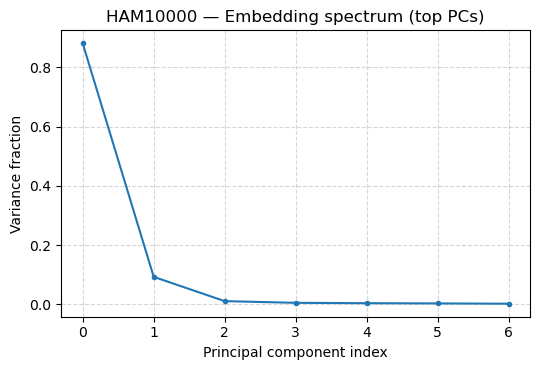

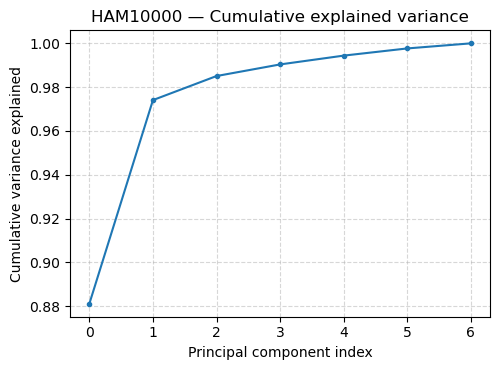

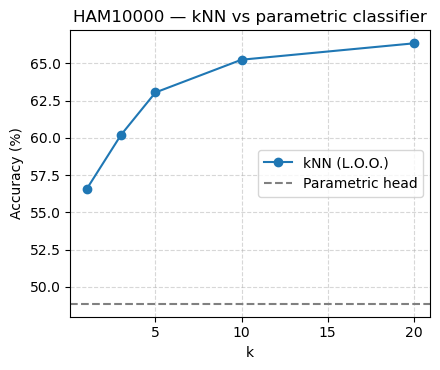

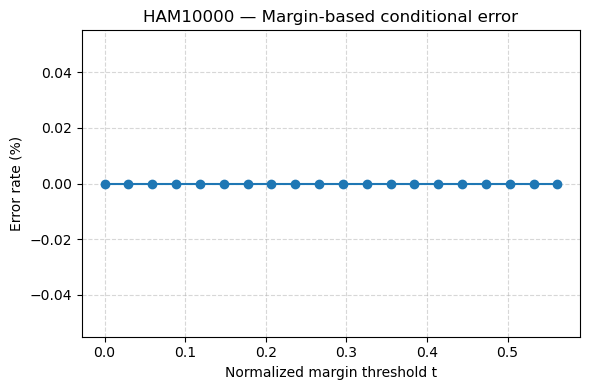

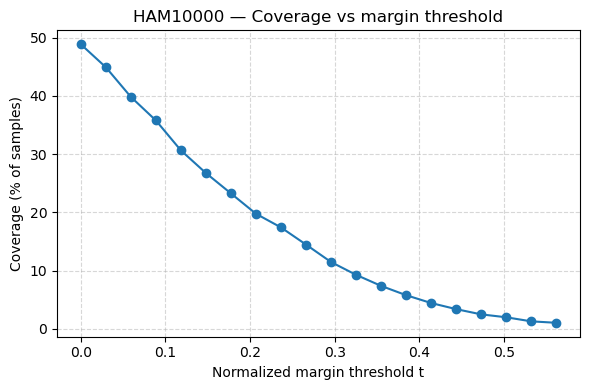

In [ ]:
# ============= Theory-ish diagnostics: geometry, kNN, margins =============
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})
model.eval()
device = next(model.parameters()).device

# ---------- 0. Get cached predictions & embeddings ----------
logits, probs, preds, y, embs = predict_loader(loader, perturb=None)
y = np.asarray(y)
preds = np.asarray(preds)
N, D = embs.shape
print(f"[Info] N={N} samples, embedding dim={D}")
base_acc = accuracy_score(y, preds) * 100
print(f"[Info] Base top-1 accuracy: {base_acc:.2f}%")

# ---------- 1. Representation spectrum & effective dimension ----------
# Center embeddings
embs_c = embs - embs.mean(axis=0, keepdims=True)
# Covariance in embedding space (D x D)
cov = np.cov(embs_c, rowvar=False)  # shape (D, D)

# Eigenvalues of covariance (variance along PCs)
evals, _ = np.linalg.eigh(cov)
evals = np.sort(np.maximum(evals, 0))[::-1]  # descending, clamp negatives

total_var = evals.sum() + 1e-12
explained = evals / total_var
cum_expl = np.cumsum(explained)

# Effective dimension (participation ratio)
eff_dim = (total_var**2) / (np.sum(evals**2) + 1e-12)
print(f"\n[Geom] Effective dimension (participation ratio): {eff_dim:.1f}")

plt.figure(figsize=(5.5, 3.8))
plt.plot(explained[: min(100, D)], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Variance fraction")
plt.title("HAM10000 — Embedding spectrum (top PCs)")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ham_embedding_spectrum.png", dpi=600, bbox_inches="tight")

plt.figure(figsize=(5.1, 3.8))
plt.plot(cum_expl[: min(100, D)], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Cumulative variance explained")
plt.title("HAM10000 — Cumulative explained variance")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ham_embedding_cumulative_variance.png", dpi=600, bbox_inches="tight")

# Small table: how many components to get X% variance
targets = [0.5, 0.8, 0.9, 0.95, 0.99]
rows = []
for t in targets:
    k = int(np.searchsorted(cum_expl, t) + 1)
    rows.append({"target_var": t, "k_components": k})
df_var = pd.DataFrame(rows)
print("\n[Geom] Components needed for target variance:")
print(df_var)

# ---------- 2. kNN classifier vs parametric head ----------
# Use embeddings as features; perform leave-one-out style kNN on the SAME set
# (this is not a proper generalization estimate but a geometry check).

ks = [1, 3, 5, 10, 20]
knn_accs = []

# Fit kNN on full set, then do "leave-one-out" by ignoring self neighbors
nbrs = KNeighborsClassifier(n_neighbors=max(ks) + 1, metric="euclidean")
nbrs.fit(embs, y)
dist, neigh_idx = nbrs.kneighbors(embs, return_distance=True)  # shape (N, maxk+1)

for k in ks:
    # For each sample, drop self index (should be first neighbor)
    neigh_k = neigh_idx[:, 1 : k + 1]
    y_pred_knn = []
    for i in range(N):
        neigh_labels = y[neigh_k[i]]
        vals, counts = np.unique(neigh_labels, return_counts=True)
        y_pred_knn.append(vals[counts.argmax()])
    y_pred_knn = np.array(y_pred_knn)
    acc_k = accuracy_score(y, y_pred_knn) * 100
    knn_accs.append(acc_k)
    print(f"[kNN] Leave-one-out kNN accuracy (k={k}): {acc_k:.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, knn_accs, "-o", label="kNN (L.O.O.)")
plt.axhline(base_acc, color="gray", linestyle="--", label="Parametric head")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("HAM10000 — kNN vs parametric classifier")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("ham_knn_vs_head.png", dpi=600, bbox_inches="tight")

# ---------- 3. Margin-based view (TCS-ish) ----------
# Margin: f_y(x) - max_{j≠y} f_j(x), using logits
logits_np = np.asarray(logits)
true_logits = logits_np[np.arange(N), y]
# set true class logit to -inf temporarily to get second-best
tmp = logits_np.copy()
tmp[np.arange(N), y] = -1e9
second_best = tmp.max(axis=1)
margins = true_logits - second_best  # raw logit margin

# Normalize by L2 norm of logit vector (scale invariance)
logit_norm = np.linalg.norm(logits_np, axis=1) + 1e-12
norm_margins = margins / logit_norm

correct = (preds == y)
m_corr = norm_margins[correct]
m_wrong = norm_margins[~correct]

print(f"\n[Margin] Mean normalized margin (correct):  {m_corr.mean():.4f}")
print(f"[Margin] Mean normalized margin (incorrect): {m_wrong.mean():.4f}")

# Margin-thresholded error rate (TCS-style margin curve)
ths = np.linspace(0.0, np.percentile(norm_margins, 99), 20)
err_cond = []
cov_cond = []
for t in ths:
    idx = np.where(norm_margins >= t)[0]
    if len(idx) == 0:
        err_cond.append(np.nan)
        cov_cond.append(0.0)
    else:
        err_cond.append(1.0 - accuracy_score(y[idx], preds[idx]))
        cov_cond.append(len(idx) / N)

err_cond = np.array(err_cond) * 100  # %
cov_cond = np.array(cov_cond) * 100  # %

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, err_cond, "-o", label="Error rate on {margin ≥ t}")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Error rate (%)")
plt.title("HAM10000 — Margin-based conditional error")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ham_margin_conditional_error.png", dpi=600, bbox_inches="tight")

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, cov_cond, "-o", label="Coverage")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Coverage (% of samples)")
plt.title("HAM10000 — Coverage vs margin threshold")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ham_margin_coverage.png", dpi=600, bbox_inches="tight")

print("\n[Done] Theory-ish diagnostics complete.")
print("Saved figures:")
print("  - ham_embedding_spectrum.png")
print("  - ham_embedding_cumulative_variance.png")
print("  - ham_knn_vs_head.png")
print("  - ham_margin_conditional_error.png")
print("  - ham_margin_coverage.png")

# Turing test Kit

In [ ]:
# ============================ Turing-test kit for HAM10000 ============================
import os, math, random
from pathlib import Path

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ------------ Config ------------
SAMPLE_N   = 60                    # how many images you want in the Turing test
OUT_DIR    = Path("ham_turing_test")
IMG_DIR    = OUT_DIR / "images"
CSV_PATH   = OUT_DIR / "ham_turing_sheet.csv"

# If your images are normalized with ImageNet stats, use these:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

OUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

device = next(model.parameters()).device
model.eval()

# ------------ 1. Run model once to get predictions + probs + embeddings ------------
logits, probs, preds, y, embs = predict_loader(loader, perturb=None)
y     = np.asarray(y)
preds = np.asarray(preds)
probs = np.asarray(probs)
conf  = probs.max(axis=1)

N = len(y)
print(f"[Info] Turing kit on N={N} test samples")

# ------------ 2. Collect image tensors in the same order as loader ------------
# IMPORTANT: assumes loader.shuffle == False
all_imgs = []
for x_tab, x_img, y_batch in loader:
    # x_img: [B, C, H, W]
    for i in range(x_img.shape[0]):
        all_imgs.append(x_img[i].cpu())
all_imgs = all_imgs
assert len(all_imgs) == N, "Image count mismatch vs predictions"

# ------------ 3. Sample a subset of indices ------------
indices = np.arange(N)
np.random.shuffle(indices)
indices = indices[:SAMPLE_N]
indices = np.sort(indices)

print(f"[Info] Sampling {SAMPLE_N} indices for Turing test:", indices[:10], "...")

# Try to grab human-readable class names if available
class_names = getattr(loader.dataset, "class_names", None)

def idx_to_name(idx):
    if class_names is not None and 0 <= idx < len(class_names):
        return str(class_names[idx])
    return f"class_{idx}"

# ------------ 4. Save images + build answer sheet ------------
rows = []
for rank, idx in enumerate(indices):
    img_tensor = all_imgs[idx]  # [C, H, W]

    # Unnormalize (if you used ImageNet stats); comment out if not needed
    t = img_tensor.clone()
    if t.shape[0] == 3:  # only for RGB
        t = t * IMAGENET_STD + IMAGENET_MEAN
    t = t.clamp(0.0, 1.0)

    pil = to_pil_image(t)
    img_name = f"sample_{idx:05d}.png"
    pil.save(IMG_DIR / img_name)

    true_id   = int(y[idx])
    pred_id   = int(preds[idx])
    pred_conf = float(conf[idx])

    true_name = idx_to_name(true_id)
    pred_name = idx_to_name(pred_id)

    rows.append({
        "global_index": idx,          # index within the full test set
        "image_file": img_name,       # file in ham_turing_test/images/
        "true_label_id": true_id,
        "true_label_name": true_name,
        "model_pred_id": pred_id,
        "model_pred_name": pred_name,
        "model_confidence": pred_conf,
        # fields for human(s) to fill in later:
        "human_label_name": "",
        "human_label_id": "",
        "human_notes": ""
    })

df = pd.DataFrame(rows)
df.to_csv(CSV_PATH, index=False)
print(f"\n[Done] Turing-test kit created.")
print(f"  Images saved to: {IMG_DIR}")
print(f"  Answer sheet CSV: {CSV_PATH}")

print("\nHow to use:")
print("  1) Give someone the images/ folder (without telling them model predictions).")
print("  2) Ask them to fill 'human_label_name' (and optionally 'human_label_id') in the CSV.")
print("  3) Save the filled CSV and run the scoring script (below) to compare human vs model.")

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

[Info] Turing kit on N=2003 test samples
[Info] Sampling 60 indices for Turing test: [ 12  35  68  90  96 108 118 130 131 203] ...

[Done] Turing-test kit created.
  Images saved to: ham_turing_test/images
  Answer sheet CSV: ham_turing_test/ham_turing_sheet.csv

How to use:
  1) Give someone the images/ folder (without telling them model predictions).
  2) Ask them to fill 'human_label_name' (and optionally 'human_label_id') in the CSV.
  3) Save the filled CSV and run the scoring script (below) to compare human vs model.


In [ ]:
# ======================= Score human vs model (Turing-style) =======================
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

CSV_PATH = Path("ham_turing_test") / "ham_turing_sheet.csv"
df = pd.read_csv(CSV_PATH)

# You can map human_label_name -> ids via class_names if you want.
# For now, try to interpret human_label_id if filled; otherwise, compare names.

# 1) Model accuracy on this subset
y_true = df["true_label_id"].to_numpy()
y_model = df["model_pred_id"].to_numpy()
acc_model = accuracy_score(y_true, y_model) * 100

print(f"Model accuracy on Turing subset: {acc_model:.2f}% (N={len(df)})")

# 2) Human accuracy
# Option A: human filled `human_label_id` as numeric IDs
if "human_label_id" in df and df["human_label_id"].notna().any():
    # interpret non-empty entries as ints, others as -1
    human_ids = []
    for v in df["human_label_id"]:
        try:
            human_ids.append(int(v))
        except Exception:
            human_ids.append(-1)
    human_ids = np.array(human_ids)
    valid_mask = human_ids >= 0
    if valid_mask.any():
        acc_human = accuracy_score(y_true[valid_mask], human_ids[valid_mask]) * 100
        print(f"Human accuracy (ID-based, valid answers only): {acc_human:.2f}% (n={valid_mask.sum()})")
    else:
        print("No valid human_label_id entries found; skipping ID-based accuracy.")

# Option B: human filled `human_label_name` matching true_label_name / model_pred_name strings
if "human_label_name" in df and df["human_label_name"].notna().any():
    # string-based comparison (exact match)
    true_names   = df["true_label_name"].astype(str).str.strip().to_list()
    human_names  = df["human_label_name"].astype(str).str.strip().to_list()
    mask_nonempty = [len(h) > 0 for h in human_names]
    if any(mask_nonempty):
        true_sel  = [t for t, m in zip(true_names, mask_nonempty) if m]
        human_sel = [h for h, m in zip(human_names, mask_nonempty) if m]
        acc_human_name = accuracy_score(true_sel, human_sel) * 100
        print(f"Human accuracy (name-based, nonempty answers): {acc_human_name:.2f}% (n={len(true_sel)})")
    else:
        print("No non-empty human_label_name entries; skipping name-based accuracy.")

# Optional: quick confusions where human + model disagree
if "human_label_name" in df:
    disagree = df[df["human_label_name"].astype(str).str.strip() != df["model_pred_name"].astype(str).str.strip()]
    print(f"\nCases where human and model disagree: {len(disagree)}/{len(df)}")
    if len(disagree) > 0:
        print(disagree[[
            "image_file", "true_label_name", "model_pred_name", "model_confidence", "human_label_name"
        ]].head(10))

Model accuracy on Turing subset: 51.67% (N=60)

Cases where human and model disagree: 60/60
         image_file true_label_name model_pred_name  model_confidence  \
0  sample_00012.png         class_5         class_5          0.272074   
1  sample_00035.png         class_5         class_5          0.380514   
2  sample_00068.png         class_2         class_5          0.179245   
3  sample_00090.png         class_5         class_4          0.512936   
4  sample_00096.png         class_5         class_4          0.975889   
5  sample_00108.png         class_5         class_5          0.238348   
6  sample_00118.png         class_5         class_5          0.262506   
7  sample_00130.png         class_5         class_4          0.456022   
8  sample_00131.png         class_5         class_5          0.260678   
9  sample_00203.png         class_5         class_5          0.357279   

   human_label_name  
0               NaN  
1               NaN  
2               NaN  
3               

In [ ]:
# ======================= Score human vs model (Turing-style) =======================
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

CSV_PATH = Path("ham_turing_test") / "ham_turing_sheet.csv"
df = pd.read_csv(CSV_PATH)

# 1) Model accuracy on this subset
y_true  = df["true_label_id"].to_numpy()
y_model = df["model_pred_id"].to_numpy()
acc_model = accuracy_score(y_true, y_model) * 100
print(f"Model accuracy on Turing subset: {acc_model:.2f}% (N={len(df)})")

# 2) Human accuracy
# -------------------------------------------------------------------
# Option A: human filled `human_label_id` as numeric IDs
if "human_label_id" in df and df["human_label_id"].notna().any():
    human_ids = []
    for v in df["human_label_id"]:
        v_str = str(v).strip()
        if v_str == "" or v_str.lower() == "nan":
            human_ids.append(-1)
        else:
            try:
                human_ids.append(int(v_str))
            except Exception:
                human_ids.append(-1)
    human_ids = np.array(human_ids)
    valid_mask = human_ids >= 0
    if valid_mask.any():
        acc_human = accuracy_score(y_true[valid_mask], human_ids[valid_mask]) * 100
        print(f"Human accuracy (ID-based, valid answers only): {acc_human:.2f}% (n={valid_mask.sum()})")
    else:
        print("No valid human_label_id entries found; skipping ID-based accuracy.")
else:
    print("Column 'human_label_id' not present or all NaN; skipping ID-based accuracy.")

# -------------------------------------------------------------------
# Option B: human filled `human_label_name` matching true_label_name strings
if "human_label_name" in df and df["human_label_name"].notna().any():
    true_names  = df["true_label_name"].astype(str).str.strip()
    human_names = df["human_label_name"].astype(str).str.strip()

    # consider only non-empty human answers
    nonempty_mask = human_names != ""
    if nonempty_mask.any():
        true_sel  = true_names[nonempty_mask].to_list()
        human_sel = human_names[nonempty_mask].to_list()
        acc_human_name = accuracy_score(true_sel, human_sel) * 100
        print(f"Human accuracy (name-based, nonempty answers): {acc_human_name:.2f}% (n={len(true_sel)})")
    else:
        print("No non-empty human_label_name entries; skipping name-based accuracy.")
else:
    print("Column 'human_label_name' not present or all NaN; skipping name-based accuracy.")

# -------------------------------------------------------------------
# 3) Optional: quick confusions where human + model disagree
#    (only on rows where human_label_name is non-empty)
if "human_label_name" in df:
    human_names  = df["human_label_name"].astype(str).str.strip()
    model_names  = df["model_pred_name"].astype(str).str.strip()
    nonempty_mask = human_names != ""

    if nonempty_mask.any():
        disagree_mask = nonempty_mask & (human_names != model_names)
        num_nonempty  = nonempty_mask.sum()
        num_disagree  = disagree_mask.sum()
        print(f"\nCases where human and model disagree: {num_disagree}/{num_nonempty} "
              f"(on rows with human answers)")
        if num_disagree > 0:
            disagree = df[disagree_mask]
            print(disagree[[
                "image_file",
                "true_label_name",
                "model_pred_name",
                "model_confidence",
                "human_label_name"
            ]].head(10))
    else:
        print("\nNo human_label_name filled yet; skipping human–model disagreement stats.")

Model accuracy on Turing subset: 51.67% (N=60)
Column 'human_label_id' not present or all NaN; skipping ID-based accuracy.
Column 'human_label_name' not present or all NaN; skipping name-based accuracy.

Cases where human and model disagree: 60/60 (on rows with human answers)
         image_file true_label_name model_pred_name  model_confidence  \
0  sample_00012.png         class_5         class_5          0.272074   
1  sample_00035.png         class_5         class_5          0.380514   
2  sample_00068.png         class_2         class_5          0.179245   
3  sample_00090.png         class_5         class_4          0.512936   
4  sample_00096.png         class_5         class_4          0.975889   
5  sample_00108.png         class_5         class_5          0.238348   
6  sample_00118.png         class_5         class_5          0.262506   
7  sample_00130.png         class_5         class_4          0.456022   
8  sample_00131.png         class_5         class_5          0.260

# OOD + sensitivity diagnostics (HAM10000)

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

[ID] N=2003, accuracy=48.88%
[ID] mean(max_conf)=0.349, mean(entropy)=1.619
[Data] Images shape: torch.Size([2003, 3, 224, 224]), num tab: 1, cat tab: 4
[Noise] mean(max_conf)=0.173, mean(entropy)=1.937
[Blank] mean(max_conf)=0.170, mean(entropy)=1.934

[Local sensitivity] image eps=0.01, mean ratio=0.013, median=0.004
[Local sensitivity] tab   eps=0.10, mean ratio=0.001, median=0.000

[Done] OOD + sensitivity diagnostics complete.
Saved figures:
  - ham_conf_id_vs_noise_blank.png
  - ham_entropy_id_vs_noise_blank.png
  - ham_local_sensitivity_img_vs_tab.png


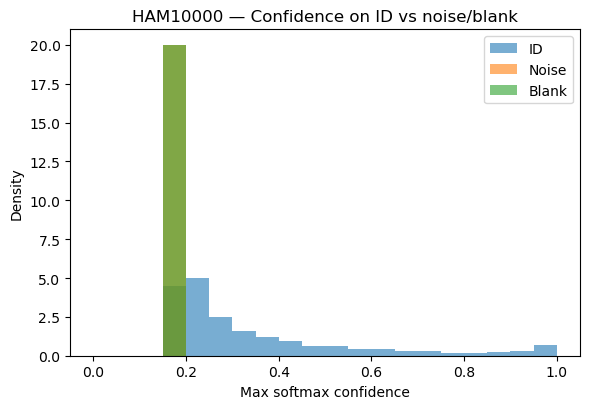

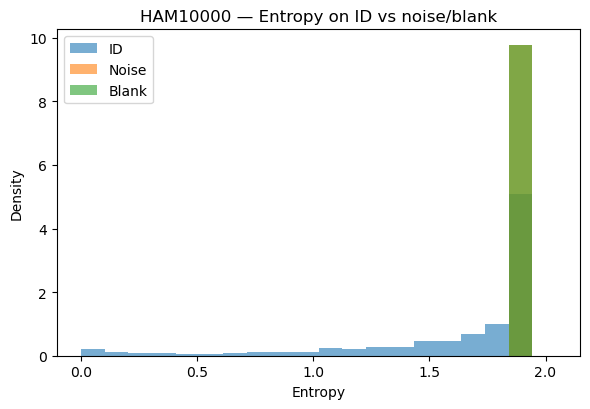

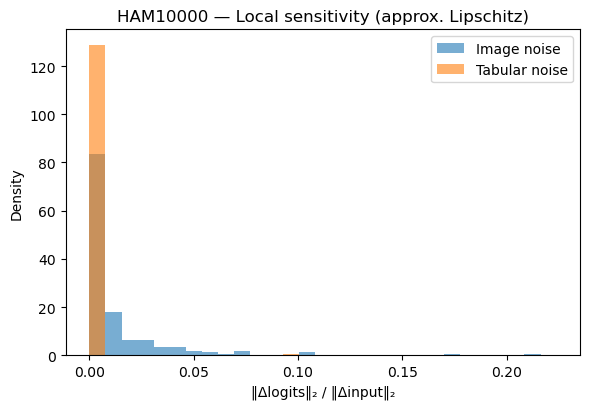

In [ ]:
# ===================== OOD + sensitivity diagnostics (HAM10000) =====================
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

device = next(model.parameters()).device
model.eval()

# ---------- 0. ID baseline stats (reuse predict_loader) ----------
logits_id, probs_id, preds_id, y_id, embs_id = predict_loader(loader, perturb=None)
probs_id = np.asarray(probs_id)
y_id     = np.asarray(y_id)
preds_id = np.asarray(preds_id)

maxconf_id = probs_id.max(axis=1)
entropy_id = -(probs_id * np.log(probs_id + 1e-12)).sum(axis=1)

print(f"[ID] N={len(y_id)}, accuracy={ (preds_id==y_id).mean()*100:.2f}%")
print(f"[ID] mean(max_conf)={maxconf_id.mean():.3f}, mean(entropy)={entropy_id.mean():.3f}")

# ---------- 1. Build noise / garbage inputs ----------
# We iterate once through loader and build three sets:
#   - ID (already have)
#   - Noise images + random tabular
#   - Blank images + random tabular

ximgs_list = []
xtab_num_list = []
xtab_cat_list = []

for x_tab, x_img, y in loader:
    x_img = x_img.to(device)
    ximgs_list.append(x_img.cpu())

    # assume structure {"num": [B, n_num], "cat": [B, n_cat]}
    num = x_tab["num"]
    cat = x_tab["cat"]
    xtab_num_list.append(num.cpu())
    xtab_cat_list.append(cat.cpu())

ximgs = torch.cat(ximgs_list, dim=0)          # [N, C, H, W]
xtab_num = torch.cat(xtab_num_list, dim=0)    # [N, n_num]
xtab_cat = torch.cat(xtab_cat_list, dim=0)    # [N, n_cat]

N, C, H, W = ximgs.shape
print(f"[Data] Images shape: {ximgs.shape}, num tab: {xtab_num.shape[1]}, cat tab: {xtab_cat.shape[1]}")

# Helper: wrap into mini-batches and run model
@torch.no_grad()
def _run_on_arrays(ximgs_arr, xtab_num_arr, xtab_cat_arr, batch_size=64):
    probs_all = []
    N = ximgs_arr.shape[0]
    for i in range(0, N, batch_size):
        sl = slice(i, min(i+batch_size, N))
        x_img = ximgs_arr[sl].to(device)
        x_tab = {
            "num": xtab_num_arr[sl].to(device),
            "cat": xtab_cat_arr[sl].to(device),
        }
        out = model(x_tab, x_img)
        probs = torch.softmax(out["logits"], dim=1)
        probs_all.append(probs.cpu())
    probs_all = torch.cat(probs_all, dim=0).numpy()
    maxconf = probs_all.max(axis=1)
    entropy = -(probs_all * np.log(probs_all + 1e-12)).sum(axis=1)
    return probs_all, maxconf, entropy

# 1a) Noise images + random tabular
torch.manual_seed(0)
noise_imgs = torch.randn_like(ximgs)  # standard normal
# Random tabular: shuffle each column independently
rand_num = xtab_num.clone()
rand_cat = xtab_cat.clone()
for j in range(rand_num.shape[1]):
    perm = torch.randperm(N)
    rand_num[:, j] = rand_num[perm, j]
for j in range(rand_cat.shape[1]):
    perm = torch.randperm(N)
    rand_cat[:, j] = rand_cat[perm, j]

probs_noise, maxconf_noise, entropy_noise = _run_on_arrays(noise_imgs, rand_num, rand_cat)
print(f"[Noise] mean(max_conf)={maxconf_noise.mean():.3f}, mean(entropy)={entropy_noise.mean():.3f}")

# 1b) Blank images + random tabular (different seed)
torch.manual_seed(1)
blank_imgs = torch.zeros_like(ximgs) + 0.5  # uniform gray
# Random tabular new shuffle
rand_num2 = xtab_num.clone()
rand_cat2 = xtab_cat.clone()
for j in range(rand_num2.shape[1]):
    perm = torch.randperm(N)
    rand_num2[:, j] = rand_num2[perm, j]
for j in range(rand_cat2.shape[1]):
    perm = torch.randperm(N)
    rand_cat2[:, j] = rand_cat2[perm, j]

probs_blank, maxconf_blank, entropy_blank = _run_on_arrays(blank_imgs, rand_num2, rand_cat2)
print(f"[Blank] mean(max_conf)={maxconf_blank.mean():.3f}, mean(entropy)={entropy_blank.mean():.3f}")

# ---------- 2. Confidence & entropy histograms ----------
bins_conf = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(maxconf_id,     bins=bins_conf, alpha=0.6, label="ID", density=True)
plt.hist(maxconf_noise,  bins=bins_conf, alpha=0.6, label="Noise", density=True)
plt.hist(maxconf_blank,  bins=bins_conf, alpha=0.6, label="Blank", density=True)
plt.xlabel("Max softmax confidence")
plt.ylabel("Density")
plt.title("HAM10000 — Confidence on ID vs noise/blank")
plt.legend()
plt.tight_layout()
plt.savefig("ham_conf_id_vs_noise_blank.png", dpi=600, bbox_inches="tight")

bins_ent = np.linspace(0.0, np.log(probs_id.shape[1])+0.1, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(entropy_id,     bins=bins_ent, alpha=0.6, label="ID", density=True)
plt.hist(entropy_noise,  bins=bins_ent, alpha=0.6, label="Noise", density=True)
plt.hist(entropy_blank,  bins=bins_ent, alpha=0.6, label="Blank", density=True)
plt.xlabel("Entropy")
plt.ylabel("Density")
plt.title("HAM10000 — Entropy on ID vs noise/blank")
plt.legend()
plt.tight_layout()
plt.savefig("ham_entropy_id_vs_noise_blank.png", dpi=600, bbox_inches="tight")

# ---------- 3. Local sensitivity (Lipschitz-ish) ----------
@torch.no_grad()
def local_sensitivity_image(xtab_num, xtab_cat, ximgs, eps=0.01, n_samples=200, batch_size=32):
    idx = np.random.choice(ximgs.shape[0], size=min(n_samples, ximgs.shape[0]), replace=False)
    ratios = []
    for start in range(0, len(idx), batch_size):
        sl_idx = idx[start:start+batch_size]
        if len(sl_idx) == 0:
            break
        x_img = ximgs[sl_idx].to(device)
        x_tab = {"num": xtab_num[sl_idx].to(device), "cat": xtab_cat[sl_idx].to(device)}

        out_base = model(x_tab, x_img)["logits"]
        noise = torch.randn_like(x_img)
        noise_flat = noise.view(noise.size(0), -1)
        norm = torch.norm(noise_flat, dim=1, keepdim=True) + 1e-12
        noise = noise / norm.view(noise.size(0), 1, 1, 1) * eps
        x_img_pert = (x_img + noise).clamp(0.0, 1.0)

        out_pert = model(x_tab, x_img_pert)["logits"]

        diff = out_pert - out_base
        diff_norm = diff.view(diff.size(0), -1).norm(dim=1)
        inp_norm = noise_flat.norm(dim=1)  # should be ~eps * sqrt(C*H*W)
        ratios.extend((diff_norm / (inp_norm + 1e-12)).cpu().numpy())
    return np.array(ratios)

@torch.no_grad()
def local_sensitivity_tabular(xtab_num, xtab_cat, ximgs, eps=0.1, n_samples=200, batch_size=32):
    idx = np.random.choice(ximgs.shape[0], size=min(n_samples, ximgs.shape[0]), replace=False)
    ratios = []
    for start in range(0, len(idx), batch_size):
        sl_idx = idx[start:start+batch_size]
        if len(sl_idx) == 0:
            break
        x_img = ximgs[sl_idx].to(device)
        num = xtab_num[sl_idx].to(device)
        cat = xtab_cat[sl_idx].to(device)

        out_base = model({"num": num, "cat": cat}, x_img)["logits"]

        noise = torch.randn_like(num)
        noise_flat = noise.view(noise.size(0), -1)
        norm = torch.norm(noise_flat, dim=1, keepdim=True) + 1e-12
        noise = noise / norm * eps
        num_pert = num + noise

        out_pert = model({"num": num_pert, "cat": cat}, x_img)["logits"]

        diff = out_pert - out_base
        diff_norm = diff.view(diff.size(0), -1).norm(dim=1)
        inp_norm = noise_flat.norm(dim=1)
        ratios.extend((diff_norm / (inp_norm + 1e-12)).cpu().numpy())
    return np.array(ratios)

sens_img = local_sensitivity_image(xtab_num, xtab_cat, ximgs, eps=0.01, n_samples=200)
sens_tab = local_sensitivity_tabular(xtab_num, xtab_cat, ximgs, eps=0.1,  n_samples=200)

print(f"\n[Local sensitivity] image eps=0.01, mean ratio={sens_img.mean():.3f}, median={np.median(sens_img):.3f}")
print(f"[Local sensitivity] tab   eps=0.10, mean ratio={sens_tab.mean():.3f}, median={np.median(sens_tab):.3f}")

plt.figure(figsize=(6.0, 4.2))
bins_s = np.linspace(0.0, max(sens_img.max(), sens_tab.max())*1.05, 30)
plt.hist(sens_img, bins=bins_s, alpha=0.6, label="Image noise", density=True)
plt.hist(sens_tab, bins=bins_s, alpha=0.6, label="Tabular noise", density=True)
plt.xlabel("‖Δlogits‖₂ / ‖Δinput‖₂")
plt.ylabel("Density")
plt.title("HAM10000 — Local sensitivity (approx. Lipschitz)")
plt.legend()
plt.tight_layout()
plt.savefig("ham_local_sensitivity_img_vs_tab.png", dpi=600, bbox_inches="tight")

print("\n[Done] OOD + sensitivity diagnostics complete.")
print("Saved figures:")
print("  - ham_conf_id_vs_noise_blank.png")
print("  - ham_entropy_id_vs_noise_blank.png")
print("  - ham_local_sensitivity_img_vs_tab.png")

# Deployment style diagnostics (Triage)

/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=

[Info] N=2003, num_classes=7

[Triage] Binary (malignant vs benign) AUC = 0.619
[Triage] Chosen threshold th* = 0.0841 with sensitivity=0.954, specificity=0.211

[Triage] Confusion matrix at th* (rows=true, cols=pred):
          pred=benign   pred=malignant
true=benign      409           1529
true=malig         3             62

[Triage] Acc=23.51%, Prec=3.90%, Recall=95.38%

[Fairness] Could not automatically fetch sex/age metadata.
           Skipping fairness analysis for now.


/largeDataVolume/zadid_workspace/iSyncTab.py:117: UserWarning: median CUDA with indices output does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  col_median = torch.nanmedian(x_num, dim=0).values
/largeDataVolume/zadid_workspace/cuml_env/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=


[Reliability] Latency stats over 20 batches:
  mean = 61.89 ms/batch
  p50  = 60.16 ms/batch
  p90  = 67.18 ms/batch
  p99  = 75.08 ms/batch

[Done] Deployment-style diagnostics (triage + fairness + latency) complete.
If ROC ran, saved: ham_triage_roc.png


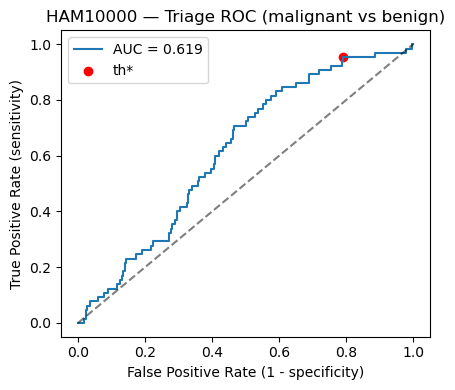

In [ ]:
# ============== Deployment-style diagnostics: triage & fairness (HAM10000) ==============
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    accuracy_score, precision_score, recall_score
)

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ------------------------------------------------------------------
# 0) Recompute predictions on the CURRENT loader so shapes match
# ------------------------------------------------------------------
logits, probs, preds, y, embs = predict_loader(loader, perturb=None)

logits = np.asarray(logits)
probs  = np.asarray(probs)
preds  = np.asarray(preds)
y      = np.asarray(y)

num_classes = probs.shape[1]
N = len(y)
print(f"[Info] N={N}, num_classes={num_classes}")

# ------------------------------------------------------------------
# 1) Define malignant vs benign mapping for triage
# ------------------------------------------------------------------
# TODO: EDIT this list based on your class mapping (HAM: melanoma, etc.).
MALIGNANT_CLASS_IDS = [0]   # <--- CHANGE THIS to the correct malignant class indices

malig_mask = np.isin(y, MALIGNANT_CLASS_IDS)
y_bin = malig_mask.astype(int)  # 1 = malignant, 0 = benign

# probability of "any malignant" = sum of probabilities over malignant classes
malig_prob = probs[:, MALIGNANT_CLASS_IDS].sum(axis=1)

# Sanity check: lengths must match
assert len(y_bin) == len(malig_prob), (
    f"Length mismatch: y_bin={len(y_bin)}, malig_prob={len(malig_prob)}"
)

# Handle degenerate case: only one class in this subset
if np.unique(y_bin).size < 2:
    print("\n[Triage] Warning: this subset has only one binary class "
          "(all benign or all malignant). ROC/AUC is undefined.")
    print("         Use a larger or more balanced test loader for triage analysis.")
else:
    # Basic ROC / AUC
    fpr, tpr, ths = roc_curve(y_bin, malig_prob)
    roc_auc = auc(fpr, tpr)
    print(f"\n[Triage] Binary (malignant vs benign) AUC = {roc_auc:.3f}")

    # Pick a threshold that achieves target sensitivity (e.g., 95%)
    TARGET_SENS = 0.95
    sens = tpr
    spec = 1 - fpr

    valid_idx = np.where(sens >= TARGET_SENS)[0]
    if len(valid_idx) == 0:
        print(f"[Triage] No threshold achieves sensitivity ≥ {TARGET_SENS:.2f}")
        best_idx = np.argmax(sens)  # highest sensitivity anyway
    else:
        # Among thresholds with desired sensitivity, pick one with highest specificity
        best_idx = valid_idx[np.argmax(spec[valid_idx])]

    th_star = ths[best_idx]
    sens_star = sens[best_idx]
    spec_star = spec[best_idx]
    print(f"[Triage] Chosen threshold th* = {th_star:.4f} "
          f"with sensitivity={sens_star:.3f}, specificity={spec_star:.3f}")

    # Confusion matrix at th*
    y_hat_bin = (malig_prob >= th_star).astype(int)
    cm = confusion_matrix(y_bin, y_hat_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print("\n[Triage] Confusion matrix at th* (rows=true, cols=pred):")
    print("          pred=benign   pred=malignant")
    print(f"true=benign   {tn:6d}         {fp:6d}")
    print(f"true=malig    {fn:6d}         {tp:6d}")

    def bin_metrics(y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        return acc, prec, rec

    acc_star, prec_star, rec_star = bin_metrics(y_bin, y_hat_bin)
    print(f"\n[Triage] Acc={acc_star*100:.2f}%, Prec={prec_star*100:.2f}%, "
          f"Recall={rec_star*100:.2f}%")

    # ROC plot
    plt.figure(figsize=(4.5, 4.0))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.scatter(fpr[best_idx], tpr[best_idx], c="red", label="th*")
    plt.xlabel("False Positive Rate (1 - specificity)")
    plt.ylabel("True Positive Rate (sensitivity)")
    plt.title("HAM10000 — Triage ROC (malignant vs benign)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("ham_triage_roc.png", dpi=600, bbox_inches="tight")

# ------------------------------------------------------------------
# 2) Fairness slices: sex + age buckets (optional, no crash if missing)
# ------------------------------------------------------------------
dataset = loader.dataset

sex_arr = None
age_arr = None

try:
    # === When you come back, you can hardcode this part if needed ===
    # Example patterns (uncomment/adapt one of these as appropriate):
    #
    # if hasattr(dataset, "meta") and isinstance(dataset.meta, pd.DataFrame):
    #     sex_arr = dataset.meta["sex"].to_numpy()
    #     age_arr = dataset.meta["age"].to_numpy()
    # elif hasattr(dataset, "df") and isinstance(dataset.df, pd.DataFrame):
    #     sex_arr = dataset.df["sex"].to_numpy()
    #     age_arr = dataset.df["age"].to_numpy()
    #
    # OR: if you have the original HAM CSV already loaded elsewhere:
    # ham_df = pd.read_csv("HAM10000_metadata_labeled.csv")
    # sex_arr = ham_df["sex"].to_numpy()
    # age_arr = ham_df["age"].to_numpy()
    #
    # For now, we try the common patterns and fall back gracefully.
    if hasattr(dataset, "meta") and isinstance(dataset.meta, pd.DataFrame):
        sex_arr = dataset.meta["sex"].to_numpy()
        age_arr = dataset.meta["age"].to_numpy()
    elif hasattr(dataset, "df") and isinstance(dataset.df, pd.DataFrame):
        sex_arr = dataset.df["sex"].to_numpy()
        age_arr = dataset.df["age"].to_numpy()
except Exception as e:
    print("\n[Fairness] Error while trying to fetch sex/age:", e)

if sex_arr is None or age_arr is None:
    print("\n[Fairness] Could not automatically fetch sex/age metadata.")
    print("           Skipping fairness analysis for now.")
else:
    sex_arr = np.asarray(sex_arr)
    age_arr = np.asarray(age_arr)

    print("\n[Fairness] Unique sex values:", np.unique(sex_arr))

    def age_bucket(a):
        try:
            a = float(a)
        except Exception:
            return "unknown"
        if np.isnan(a):
            return "unknown"
        if a < 40:
            return "<40"
        elif a < 60:
            return "40-59"
        elif a < 80:
            return "60-79"
        else:
            return "80+"

    age_buckets = np.array([age_bucket(a) for a in age_arr])

    def show_slice_metrics(mask, name):
        if mask.sum() == 0:
            print(f"[Fairness] {name}: no samples.")
            return
        y_true_bin = y_bin[mask]
        # If y_hat_bin exists (ROC ran), use that; else default to threshold 0.5
        if "y_hat_bin" in globals():
            y_pred_bin = y_hat_bin[mask]
        else:
            y_pred_bin = (malig_prob[mask] >= 0.5).astype(int)

        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        acc = accuracy_score(y_true_bin, y_pred_bin)
        print(f"[Fairness] {name}: n={mask.sum()}, "
              f"Acc={acc*100:.2f}%, Sens={sens*100:.2f}%, Spec={spec*100:.2f}%")

    print("\n[Fairness] Sex slices (on triage task)")
    for v in np.unique(sex_arr):
        m = sex_arr == v
        show_slice_metrics(m, f"sex={v}")

    print("\n[Fairness] Age slices (on triage task)")
    for b in np.unique(age_buckets):
        m = age_buckets == b
        show_slice_metrics(m, f"age_bucket={b}")

# ------------------------------------------------------------------
# 3) Simple reliability: latency stats on this hardware
# ------------------------------------------------------------------
import time

def measure_latency(loader, num_batches=10):
    times = []
    with torch.no_grad():
        for bi, (x_tab, x_img, y_batch) in enumerate(loader):
            if bi >= num_batches:
                break
            x_tab, x_img, _ = _to_device(x_tab, x_img, None, dev=device)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.time()
            out = model(x_tab, x_img)
            _ = out["logits"]
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t1 = time.time()
            times.append(t1 - t0)
    return np.array(times)

lat = measure_latency(loader, num_batches=20)
if len(lat) > 0:
    print("\n[Reliability] Latency stats over 20 batches:")
    print(f"  mean = {lat.mean()*1000:.2f} ms/batch")
    print(f"  p50  = {np.percentile(lat, 50)*1000:.2f} ms/batch")
    print(f"  p90  = {np.percentile(lat, 90)*1000:.2f} ms/batch")
    print(f"  p99  = {np.percentile(lat, 99)*1000:.2f} ms/batch")
else:
    print("\n[Reliability] Not enough batches for latency measurement.")

print("\n[Done] Deployment-style diagnostics (triage + fairness + latency) complete.")
print("If ROC ran, saved: ham_triage_roc.png")